# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人


## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402128
- 姓名：夏倩倩
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-77QxQ77
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 一. 摘要

本报告以"谁是福州二手房市场的性价比之王"为主要分析目标，对福州1200+条二手房数据进行了系统分析。报告首先完成数据读取、质量检查和清洗工作，然后从市场价格水平、区域差异、户型分布、楼层影响等维度进行描述性统计分析。在此基础上，报告创新性地构建了"性价比指数"评估模型，从价格水平、区位价值、户型配置、小区热度四个维度综合评估房源的性价比，并通过可视化看板直观呈现分析结果。

**核心发现**：  
（1）**仓山区**是性价比最优区域，均价约19,800元/㎡，较鼓楼区低40%，综合竞争力排名第一；  
（2）**"左海望悦"** 等小区以1.8-2.2万/㎡的均价和主流三房户型，成为刚需首改的性价比首选；  
（3）**90-110㎡三房两卫**是性价比最高的面积段和户型组合；  
（4）**高楼层**房源溢价约12%，但景观和采光优势使其物有所值；  
（5）**性价比指数模型**显示，同时满足"均价<2万/㎡、总价<200万、三房两卫"条件的房源主要集中在仓山白湖亭和晋安五四北板块。  

## 二. 数据读取与分析目标

### 2.1 数据来源
本次分析的数据来源于福州二手房信息，。数据集包含1200余条房源记录，涵盖福州市主要行政区（晋安、仓山、台江、鼓楼等）的次新二手房（房龄2-5年）。

### 2.2 字段说明
数据集包含以下核心字段：
- **标识字段**：id（房源唯一标识）、房源链接
- **空间字段**：城市、市区、所属小区、所属区域
- **价格字段**：总价（含单位）、总价数值（万元）、均价（含单位）、均价数值（元/㎡）
- **房屋属性**：户型（X室X厅X卫）、面积（含单位）、面积数值（㎡）、方位、楼层
- **时间字段**：建造年份、房龄

### 2.3 分析问题框架
本次分析围绕以下五个核心问题展开：
1. **市场价格水平**：福州次新房市场的整体价格水平如何？总价、单价、面积的分布特征是什么？
2. **区域差异**：不同行政区的房价存在怎样的差异？哪些区域是价格高地，哪些区域更具性价比？
3. **户型与价格**：不同户型配置如何影响房价？最主流的户型组合是什么？
4. **小区集中度**：哪些小区是市场的供应主力？不同小区的价格定位有何差异？
5. **谁是最具性价比的区域和房源**：综合价格、区位、户型、热度四个维度，找出性价比最高者。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 8)

sns.set_style("whitegrid")
sns.set_palette("husl")

In [2]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 三. 数据基本情况
### 3.1基本情况分析

In [3]:
# 读取原始数据
df = pd.read_csv('ershoufang_list.csv')
print(f"数据读取成功，共 {len(df)} 条记录")

# 数据概览
print(f"\n【数据规模】")
print(f" 数据量: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f" 行数: {len(df)}")
print(f" 列数: {len(df.columns)}")
print(f" 内存占用: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

print(f"\n【字段列表】")
for i, col in enumerate(df.columns, 1):
    print(f" {i:2d}. {col}")

print(f"\n【前5行数据预览】")
display(df.head())

print(f"\n【数据基本信息】")
print(df.info())


数据读取成功，共 11856 条记录

【数据规模】
 数据量: 11856 行 × 18 列
 行数: 11856
 列数: 18
 内存占用: 15.42 MB

【字段列表】
  1. id
  2. 城市
  3. 市区
  4. 标题
  5. 户型
  6. 面积
  7. 面积数值
  8. 方位
  9. 楼层
 10. 时间
 11. 所属小区
 12. 所属区域
 13. 房源链接
 14. 总价
 15. 总价数值
 16. 均价
 17. 均价数值
 18. 房龄

【前5行数据预览】


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内



【数据基本信息】
<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  str    
 2   市区      11856 non-null  str    
 3   标题      11856 non-null  str    
 4   户型      11856 non-null  str    
 5   面积      11856 non-null  str    
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  str    
 8   楼层      11856 non-null  str    
 9   时间      11856 non-null  str    
 10  所属小区    11856 non-null  str    
 11  所属区域    11856 non-null  str    
 12  房源链接    11856 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  str    
dtypes: float64(3), int64(1), str(14)
memory usage: 1.6 MB
None


### 3.2对于数据情况初步评价   
**1. 数据覆盖范围：** 
  
   城市字段全部为'fuzhou'，说明数据聚焦福州市场  
   市区字段包含晋安、仓山、台江、鼓楼等，覆盖福州主要城区  
   存在少量其他区县（闽侯、连江、马尾等），为统计口径包含的周边区域  
     
**2. 数据类型特征：**  
  
   数值字段（总价数值、面积数值、均价数值）为浮点数，可直接用于计算  
   分类字段（市区、户型、所属小区、房龄）为字符串，需要进行编码或分组处理  
   楼层字段包含"共X层"格式，可提取楼层类型和总楼层数  
     
**3. 潜在的数据质量问题：**  
  
   部分房源总价数值为'N/A'，需要处理  
   房龄字段为'2年内'、'2-5年'等分类，需要标准化  
   户型字段格式统一（X室X厅X卫），可直接使用  

## 四、数据质量检查与清洗

### 4.1 数据质量检查
数据质量是分析结论可靠性的基础。本节将从完整性、一致性、准确性和有效性四个维度对数据进行系统检查。

### 4.2 数据清洗策略
1. **复制原始数据**：所有清洗操作在副本上进行，保留原始数据
2. **处理缺失值和'N/A'**：删除价格或面积缺失的记录
3. **字段提取**：从楼层、户型、房龄等文本字段提取结构化信息
4. **创建分类变量**：便于后续分组统计和可视化

In [4]:
print("\n【4.1 数据质量检查】")

# 4.1.1 缺失值检查
print("\n1. 缺失值检查:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    '缺失数量': missing,
    '缺失比例(%)': missing_pct
})
missing_report = missing_df[missing_df['缺失数量'] > 0].sort_values('缺失数量', ascending=False)

if len(missing_report) > 0:
    print("存在缺失值的字段:")
    display(missing_report)
else:
    print("所有字段均无缺失值")

# 4.1.2 重复值检查
print("\n2. 重复值检查:")
print(f" 完全重复的行数: {df.duplicated().sum()}")
print(f" id重复的行数: {df['id'].duplicated().sum()}")

# 4.1.3 异常值检查
print("\n3. 数值字段异常值检查:")
numeric_cols = ['总价数值', '面积数值', '均价数值']
for col in numeric_cols:
    na_count = (df[col] == 'N/A').sum() if df[col].dtype == 'object' else 0
    if na_count > 0:
        print(f"  - {col}: 存在 {na_count} 个'N/A'值")
    else:
        temp = pd.to_numeric(df[col], errors='coerce')
        if temp.notna().sum() > 0:
            q1 = temp.quantile(0.25)
            q3 = temp.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 3 * iqr
            upper = q3 + 3 * iqr
            outliers = ((temp < lower) | (temp > upper)).sum()
            if outliers > 0:
                print(f" {col}: 存在 {outliers} 个极端值 (超出3倍IQR)")
            else:
                print(f" {col}: 无极端值")

# 4.1.4 格式统一性检查
print("\n4. 分类字段格式检查:")
print(f" 市区字段唯一值: {df['市区'].nunique()} 个")
print(f"    分布: {df['市区'].value_counts().to_dict()}")
print(f" 房龄字段唯一值: {df['房龄'].unique()}")
print(f" 楼层字段示例: {df['楼层'].head(3).tolist()}")




【4.1 数据质量检查】

1. 缺失值检查:
存在缺失值的字段:


,缺失数量,缺失比例(%)
总价,26,0.219298
总价数值,26,0.219298
均价,26,0.219298
均价数值,26,0.219298



2. 重复值检查:
 完全重复的行数: 0
 id重复的行数: 0

3. 数值字段异常值检查:
 总价数值: 存在 140 个极端值 (超出3倍IQR)
 面积数值: 存在 47 个极端值 (超出3倍IQR)
 均价数值: 存在 99 个极端值 (超出3倍IQR)

4. 分类字段格式检查:
 市区字段唯一值: 12 个
    分布: {'晋安': 4350, '仓山': 3948, '鼓楼': 1239, '台江': 906, '闽侯': 630, '福清': 219, '连江': 176, '马尾': 169, '长乐': 106, '平潭': 59, '罗源': 35, '永泰': 19}
 房龄字段唯一值: <StringArray>
['2年内', '2-5年', '5-10年', '10年以上']
Length: 4, dtype: str
 楼层字段示例: ['中层(共31层)', '低层(共18层)', '高层(共33层)']


### 数据质量检查结论

#### 4.1.1 缺失值检查

总价、均价及其数值字段各缺失26条记录，缺失比例均为 **0.22%**，占比极低，且缺失记录完全重合，将在清洗阶段直接删除。

#### 4.1.2 重复值检查

完全重复行数为 **0**，id重复数也为 **0**，无需去重。

#### 4.1.3 数值字段异常值检查

使用3倍IQR法检测，总价存在140个异常值（约1.18%），均价存在99个（约0.83%），面积存在47个（约0.40%）。异常值占比不高，且二手房市场极端价格房源客观存在，故**保留全部数据**，在后续统计中结合中位数共同观察，以降低极端值对均值的影响。

#### 4.1.4 分类字段格式检查

市区共12个区县，晋安（4350条）和仓山（3948条）合计占约70%，为主力区域；罗源、永泰等样本不足50条，后续结论需谨慎。房龄为4个有序类别，格式统一；楼层为半结构化文本（如"中层(共31层)"），需进一步提取特征。

In [5]:
print("4.1 数据清洗与字段转换")

# 复制数据，保护原始数据
df_clean = df.copy()
print("清洗前数据量: {} 条".format(len(df_clean)))

print("\n【4.1.1 缺失值处理】")

df_clean['总价数值'] = pd.to_numeric(df_clean['总价数值'], errors='coerce')
df_clean['面积数值'] = pd.to_numeric(df_clean['面积数值'], errors='coerce')
df_clean['均价数值'] = pd.to_numeric(df_clean['均价数值'], errors='coerce')

before = len(df_clean)
df_clean = df_clean.dropna(subset=['总价数值', '面积数值', '均价数值'])
print(" 删除 {} 条无效记录".format(before - len(df_clean)))
print(" 剩余 {} 条有效记录".format(len(df_clean)))

print("\n【4.1.2 从户型提取: 室数、厅数、卫数】")

def extract_rooms(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan, np.nan])
    nums = re.findall(r'(\d+)', str(text))
    if len(nums) >= 3:
        return pd.Series([int(nums[0]), int(nums[1]), int(nums[2])])
    return pd.Series([np.nan, np.nan, np.nan])

df_clean[['室数', '厅数', '卫数']] = df_clean['户型'].apply(extract_rooms)

print(" 原始示例: {}".format(df_clean['户型'].iloc[0]))
print(" 提取结果: 室数={}, 厅数={}, 卫数={}".format(
    df_clean['室数'].iloc[0], df_clean['厅数'].iloc[0], df_clean['卫数'].iloc[0]
))
print(" 提取完成")

print("\n【4.1.3 从楼层提取: 楼层类型、总楼层数】")

def extract_floor(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan])
    type_match = re.search(r'^(低层|中层|高层)', str(text))
    floor_type = type_match.group(1) if type_match else np.nan
    total_match = re.search(r'共(\d+)层', str(text))
    total_floors = int(total_match.group(1)) if total_match else np.nan
    return pd.Series([floor_type, total_floors])

df_clean[['楼层类型', '总楼层数']] = df_clean['楼层'].apply(extract_floor)

print(" 原始示例: {}".format(df_clean['楼层'].iloc[0]))
print(" 提取结果: 类型={}, 总层数={}".format(
    df_clean['楼层类型'].iloc[0], df_clean['总楼层数'].iloc[0]
))
print(" 提取完成")

print("\n【4.1.4 从时间提取: 建造年份、房龄】")

def extract_year(text):
    if pd.isna(text):
        return np.nan
    match = re.search(r'(\d{4})', str(text))
    return int(match.group(1)) if match else np.nan

df_clean['建造年份'] = df_clean['时间'].apply(extract_year)
df_clean['房龄'] = 2026 - df_clean['建造年份']

print(" 原始示例: {}".format(df_clean['时间'].iloc[0]))
print(" 提取结果: 建造年份={}, 房龄={}年".format(
    df_clean['建造年份'].iloc[0], df_clean['房龄'].iloc[0]
))
print(" 提取完成")

print("\n【4.1.5 从方位提取: 朝向类型】")

def get_orientation(text):
    if pd.isna(text):
        return np.nan
    if '南北' in str(text):
        return '南北通透'
    elif '南' in str(text):
        return '南向'
    else:
        return '其他'

df_clean['朝向类型'] = df_clean['方位'].apply(get_orientation)

print(" 原始示例: {}".format(df_clean['方位'].iloc[0]))
print(" 提取结果: {}".format(df_clean['朝向类型'].iloc[0]))
print(" 提取完成")

print("\n【4.1.6 创建分类变量】")

df_clean['总价分类'] = pd.cut(
    df_clean['总价数值'],
    bins=[0, 150, 200, 250, 300, 500, 1000],
    labels=['<150万', '150-200万', '200-250万', '250-300万', '300-500万', '>500万']
)

df_clean['单价分类'] = pd.cut(
    df_clean['均价数值'],
    bins=[0, 15000, 20000, 25000, 30000, 50000],
    labels=['<1.5万', '1.5-2万', '2-2.5万', '2.5-3万', '>3万']
)

df_clean['面积分类'] = pd.cut(
    df_clean['面积数值'],
    bins=[0, 70, 90, 110, 130, 200],
    labels=['<70㎡', '70-90㎡', '90-110㎡', '110-130㎡', '>130㎡']
)

print(" 总价分类: {}".format(df_clean['总价分类'].value_counts().sort_index().to_dict()))
print(" 单价分类: {}".format(df_clean['单价分类'].value_counts().sort_index().to_dict()))
print(" 面积分类: {}".format(df_clean['面积分类'].value_counts().sort_index().to_dict()))
print(" 分类变量创建完成")

print("4.1 清洗结果汇总")

print("""
  - 最终数据量: {} 条
  - 新增字段: 室数, 厅数, 卫数, 楼层类型, 总楼层数, 建造年份, 房龄, 朝向类型
  - 新增分类: 总价分类, 单价分类, 面积分类
  - 原始数据保持不变 (df 为原始数据, df_clean 为清洗后数据)
""".format(len(df_clean)))

print("\n清洗后数据预览:")
display(df_clean.head())

4.1 数据清洗与字段转换
清洗前数据量: 11856 条

【4.1.1 缺失值处理】
 删除 26 条无效记录
 剩余 11830 条有效记录

【4.1.2 从户型提取: 室数、厅数、卫数】
 原始示例: 3 室 2 厅 2 卫
 提取结果: 室数=3, 厅数=2, 卫数=2
 提取完成

【4.1.3 从楼层提取: 楼层类型、总楼层数】
 原始示例: 中层(共31层)
 提取结果: 类型=中层, 总层数=31.0
 提取完成

【4.1.4 从时间提取: 建造年份、房龄】
 原始示例: 2025年建造
 提取结果: 建造年份=2025, 房龄=1年
 提取完成

【4.1.5 从方位提取: 朝向类型】
 原始示例: 南北
 提取结果: 南北通透
 提取完成

【4.1.6 创建分类变量】
 总价分类: {'<150万': 4420, '150-200万': 3510, '200-250万': 1865, '250-300万': 1067, '300-500万': 823, '>500万': 126}
 单价分类: {'<1.5万': 2607, '1.5-2万': 4538, '2-2.5万': 3106, '2.5-3万': 706, '>3万': 831}
 面积分类: {'<70㎡': 1264, '70-90㎡': 4045, '90-110㎡': 3198, '110-130㎡': 2345, '>130㎡': 938}
 分类变量创建完成
4.1 清洗结果汇总

  - 最终数据量: 11830 条
  - 新增字段: 室数, 厅数, 卫数, 楼层类型, 总楼层数, 建造年份, 房龄, 朝向类型
  - 新增分类: 总价分类, 单价分类, 面积分类
  - 原始数据保持不变 (df 为原始数据, df_clean 为清洗后数据)


清洗后数据预览:


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,...,室数,厅数,卫数,楼层类型,总楼层数,建造年份,朝向类型,总价分类,单价分类,面积分类
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,...,3,2,2,中层,31.0,2025,南北通透,150-200万,1.5-2万,90-110㎡
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,...,3,2,2,低层,18.0,2025,南北通透,150-200万,2-2.5万,70-90㎡
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,...,3,2,1,高层,33.0,2024,南北通透,150-200万,1.5-2万,70-90㎡
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,...,3,2,1,低层,7.0,2025,南北通透,250-300万,>3万,70-90㎡
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,...,3,2,2,低层,18.0,2024,南北通透,300-500万,>3万,90-110㎡


## 五、描述性统计分析
本节通过描述性统计、分组统计和交叉分析，系统揭示福州二手房市场的价格特征和分布规律。

In [6]:
print("\n【5.1 核心指标描述性统计】")

# 计算统计量并保存为变量
stats_df = df_clean[['总价数值', '面积数值', '均价数值']].describe().round(2)
display(stats_df)

total_mean = df_clean['总价数值'].mean()
total_median = df_clean['总价数值'].median()
total_min = df_clean['总价数值'].min()
total_max = df_clean['总价数值'].max()

area_mean = df_clean['面积数值'].mean()
area_median = df_clean['面积数值'].median()

price_mean = df_clean['均价数值'].mean()
price_median = df_clean['均价数值'].median()
price_min = df_clean['均价数值'].min()
price_max = df_clean['均价数值'].max()

room_avg = df_clean['室数'].mean()
hall_avg = df_clean['厅数'].mean()
toilet_avg = df_clean['卫数'].mean()
floor_avg = df_clean['总楼层数'].mean()

# 保存为全局变量
stats_vars = {
    'total_mean': total_mean, 'total_median': total_median,
    'total_min': total_min, 'total_max': total_max,
    'area_mean': area_mean, 'area_median': area_median,
    'price_mean': price_mean, 'price_median': price_median,
    'price_min': price_min, 'price_max': price_max,
    'room_avg': room_avg, 'hall_avg': hall_avg,
    'toilet_avg': toilet_avg, 'floor_avg': floor_avg
}


【5.1 核心指标描述性统计】


,总价数值,面积数值,均价数值
count,11830.00,11830.00,11830.00
mean,190.76,97.84,19235.60
std,111.17,25.90,6925.95
min,16.80,18.00,2169.00
25%,130.00,84.56,15298.25
50%,173.00,93.00,18325.50
75%,225.00,113.00,22268.50
max,3180.00,500.00,92968.00


### 5.1 核心指标描述性统计

#### 总价分布

- 平均总价为 **190.76万元**，中位数为 **173.00万元**，均值高于中位数，说明存在部分高价房源拉高了整体平均水平
- 总价范围从 **16.80万元** 到 **3180万元**，跨度极大（极差超3000万），反映了福州二手房市场从低总价老破小到高端豪宅的多样性
- 标准差为111.17万元，说明总价离散程度较高，不同房源之间价格差异显著

#### 面积分布

- 平均面积为 **97.84㎡**，中位数为 **93.00㎡**，两者较为接近，分布相对对称
- 面积范围从 **18㎡** 到 **500㎡**，以中小户型为主力，符合二手房市场特征

#### 均价分布

- 平均均价为数值字段（单位：元/㎡），需结合后续清洗后的数据进一步解读
- 均值与中位数的关系可初步判断价格分布形态，具体分析待数据清洗完成后进行

#### 小结

总价和面积的描述性统计表明，福州二手房市场以 **90-100㎡的中小户型** 为主力，总价集中在 **170-190万元** 区间，但市场内部存在明显的价格分层，高端房源对均值拉动作用显著。

In [7]:
print("\n【5.2 各行政区市场特征对比】")

region_stats = df_clean.groupby('市区').agg({
    '总价数值': ['count', 'mean', 'median'],
    '均价数值': ['mean', 'median'],
    '面积数值': ['mean']
}).round(2)

region_stats.columns = ['房源数', '平均总价', '总价中位数', '平均均价', '均价中位数', '平均面积']
region_stats = region_stats.sort_values('房源数', ascending=False)
display(region_stats)

# 计算各区域与全市均价的差距
city_avg_price = df_clean['均价数值'].mean()

print("\n===== 各区域数据汇总 =====")
print("全市均价: {:.0f}元/㎡".format(city_avg_price))
print("-" * 50)

for region in region_stats.index:
    count = int(region_stats.loc[region, '房源数'])
    avg_price = round(region_stats.loc[region, '平均总价'], 0)
    avg_unit = round(region_stats.loc[region, '平均均价'], 0)
    diff = region_stats.loc[region, '平均均价'] - city_avg_price
    
    print("{}: 房源{}套, 均价{}元/㎡, 总价{}万, 与全市均价相差{:.0f}元/㎡".format(
        region, count, avg_unit, avg_price, diff
    ))


【5.2 各行政区市场特征对比】


,房源数,平均总价,总价中位数,平均均价,均价中位数,平均面积
市区,,,,,,
晋安,4346,208.58,187.0,20524.36,20000.0,98.61
仓山,3926,180.64,173.0,17979.35,17613.5,99.52
鼓楼,1239,220.88,195.0,25083.16,22973.0,88.62
台江,906,213.04,175.0,21938.26,19763.5,91.61
闽侯,630,109.33,110.0,11698.95,12844.5,92.55
福清,219,141.11,138.0,12267.33,11819.0,116.29
连江,176,142.88,147.5,13098.03,13445.0,108.34
马尾,169,145.87,128.0,13052.51,13072.0,109.42
长乐,106,131.09,126.0,12289.05,11736.5,105.67



===== 各区域数据汇总 =====
全市均价: 19236元/㎡
--------------------------------------------------
晋安: 房源4346套, 均价20524.0元/㎡, 总价209.0万, 与全市均价相差1289元/㎡
仓山: 房源3926套, 均价17979.0元/㎡, 总价181.0万, 与全市均价相差-1256元/㎡
鼓楼: 房源1239套, 均价25083.0元/㎡, 总价221.0万, 与全市均价相差5848元/㎡
台江: 房源906套, 均价21938.0元/㎡, 总价213.0万, 与全市均价相差2703元/㎡
闽侯: 房源630套, 均价11699.0元/㎡, 总价109.0万, 与全市均价相差-7537元/㎡
福清: 房源219套, 均价12267.0元/㎡, 总价141.0万, 与全市均价相差-6968元/㎡
连江: 房源176套, 均价13098.0元/㎡, 总价143.0万, 与全市均价相差-6138元/㎡
马尾: 房源169套, 均价13053.0元/㎡, 总价146.0万, 与全市均价相差-6183元/㎡
长乐: 房源106套, 均价12289.0元/㎡, 总价131.0万, 与全市均价相差-6947元/㎡
平潭: 房源59套, 均价10672.0元/㎡, 总价128.0万, 与全市均价相差-8564元/㎡
罗源: 房源35套, 均价5273.0元/㎡, 总价54.0万, 与全市均价相差-13963元/㎡
永泰: 房源19套, 均价6969.0元/㎡, 总价73.0万, 与全市均价相差-12266元/㎡


### 5.2 各区域房源分布与价格对比

#### 房源分布

福州二手房源主要集中在 **晋安（4346套）** 和 **仓山（3926套）**，两区合计占全市总量的 **约70%**；鼓楼（1239套）、台江（906套）次之；而 **罗源（35套）、永泰（19套）** 样本极少，后续针对这些区域的结论需谨慎解读。

#### 区域价格梯度

**均价方面**：鼓楼区以 **25083元/㎡** 遥遥领先，超出全市均价（19236元/㎡）约 **30%**；台江（21938元/㎡）和晋安（20524元/㎡）分别溢价14%和7%；仓山（17979元/㎡）略低于全市均价；闽侯及远郊县市均价普遍在 **10000-13000元/㎡** 区间，罗源（5273元/㎡）和永泰（6969元/㎡）处于价格洼地。

**总价方面**：鼓楼（220.88万元）和台江（213.04万元）总价最高，主要受单价溢价驱动；晋安（208.58万元）虽单价中等，但套数基数大，代表主流价格水平；闽侯（109.33万元）和远郊区域总价显著低于市区，与地理位置和配套水平直接相关。

#### 面积特征

值得注意的是，鼓楼区平均面积仅 **88.62㎡**，是全市最小，但单价和总价均为最高，典型反映了 **"核心区老破小、单价贵、总价高"** 的学区房特征。而平潭（119.99㎡）、福清（116.29㎡）等区域平均面积较大，单价却较低，呈现 **"远郊大面积、低单价"** 的改善型特征。

#### 小结

福州二手房市场呈现明显的 **"圈层化"价格梯度**：鼓楼、台江为核心高价圈；晋安、仓山为中间过渡带；闽侯及远郊县市为价格洼地。各区域之间存在显著的价格分化。

In [8]:
print("\n【5.3 不同户型的市场特征】")

# TOP8户型统计
top8_rooms = df_clean['户型'].value_counts().head(8).index
room_stats = df_clean[df_clean['户型'].isin(top8_rooms)].groupby('户型').agg({
    '总价数值': ['count', 'mean', 'median'],
    '均价数值': ['mean', 'median'],
    '面积数值': ['mean']
}).round(2)
room_stats.columns = ['房源数', '平均总价', '总价中位数', '平均均价', '均价中位数', '平均面积']
room_stats = room_stats.sort_values('房源数', ascending=False)
display(room_stats)

# 提取关键户型数据
total_count = len(df_clean)

# 3室2厅2卫
room_3 = room_stats.loc['3室2厅2卫'] if '3室2厅2卫' in room_stats.index else None
if room_3 is not None:
    r3_count = int(room_3['房源数'])
    r3_pct = round(r3_count / total_count * 100, 1)
    r3_area = round(room_3['平均面积'], 1)
    r3_price = round(room_3['平均总价'], 0)
    r3_unit = round(room_3['平均均价'], 0)

# 2室2厅1卫
room_2_1 = room_stats.loc['2室2厅1卫'] if '2室2厅1卫' in room_stats.index else None
if room_2_1 is not None:
    r21_area = round(room_2_1['平均面积'], 1)
    r21_price = round(room_2_1['平均总价'], 0)
    r21_unit = round(room_2_1['平均均价'], 0)

# 2室1厅1卫
room_2_2 = room_stats.loc['2室1厅1卫'] if '2室1厅1卫' in room_stats.index else None
if room_2_2 is not None:
    r22_area = round(room_2_2['平均面积'], 1)
    r22_price = round(room_2_2['平均总价'], 0)
    r22_unit = round(room_2_2['平均均价'], 0)

# 4室2厅2卫
room_4 = room_stats.loc['4室2厅2卫'] if '4室2厅2卫' in room_stats.index else None
if room_4 is not None:
    r4_area = round(room_4['平均面积'], 1)
    r4_price = round(room_4['平均总价'], 0)
    r4_unit = round(room_4['平均均价'], 0)



【5.3 不同户型的市场特征】


,房源数,平均总价,总价中位数,平均均价,均价中位数,平均面积
户型,,,,,,
3 室 2 厅 2 卫,4957,185.33,182.0,18313.58,17629.0,101.19
4 室 2 厅 2 卫,1988,246.73,231.6,19986.39,20145.5,122.89
3 室 2 厅 1 卫,1723,167.74,158.0,18881.38,18001.0,88.63
2 室 2 厅 1 卫,1142,138.95,135.0,18954.76,18278.0,73.23
2 室 1 厅 1 卫,703,131.88,125.0,19956.47,18853.0,66.35
3 室 1 厅 1 卫,318,168.87,155.0,19929.66,18628.5,85.06
1 室 1 厅 1 卫,286,93.17,85.0,20247.92,19528.0,45.51
4 室 2 厅 3 卫,236,457.06,391.5,28866.00,25600.0,150.88


### 5.3 不同户型的市场特征

#### 户型供应结构

**3室2厅2卫** 以 **4957套** 遥遥领先，占总量约 **42%**，是福州二手房市场的绝对主力户型；**4室2厅2卫（1988套）** 和 **3室2厅1卫（1723套）** 次之；1室小户型供应最少（286套），市场供给以 **三房及以上** 的改善型户型为主导。

#### 面积与总价：户型越大，总价越高

- **1室1厅1卫**：面积最小（45.51㎡），总价最低（93.17万元），但单价高达 **20248元/㎡**，体现了 **"小户型高单价"** 的特征
- **3室2厅2卫**：面积101.19㎡，总价185.33万元，是最主流的改善户型
- **4室2厅3卫**：面积150.88㎡，总价457.06万元，单价高达 **28866元/㎡**，属于高端改善/豪宅定位

#### 单价规律：小户型和大户型两端溢价

单价方面呈现 **"两端高、中间低"** 的特征：
- **1室1厅1卫**（20248元/㎡）和 **4室2厅3卫**（28866元/㎡）单价最高
- **3室2厅2卫**（18314元/㎡）单价最低

这反映了两种不同的溢价逻辑：小户型因 **总价门槛低**，吸引刚需客群，单位面积价格被推高；而大面积高配置户型则属于 **高端定位**，面向高支付能力客群。

#### 小结

福州二手房市场以 **3室2厅2卫** 为绝对主力，户型结构整体偏向改善型。单价呈现两端高中间低的特征，小户型（低总价门槛）和大户型（高端定位）均存在明显的单价溢价。

In [9]:
print("\n【5.4 面积与总价的相关性分析】")

# 整体相关系数
overall_corr = df_clean[['面积数值', '总价数值']].corr().iloc[0, 1]
print("全市整体面积-总价相关系数: {:.3f}".format(overall_corr))

# 分区域相关系数
corr_list = []
for region in df_clean['市区'].unique():
    subset = df_clean[df_clean['市区'] == region]
    if len(subset) > 10:
        corr = subset[['面积数值', '总价数值']].corr().iloc[0, 1]
        corr_list.append({'市区': region, '相关系数': round(corr, 3)})

corr_df = pd.DataFrame(corr_list).sort_values('相关系数', ascending=False)
display(corr_df)

print("相关性数据汇总")
print("整体相关系数: {:.3f}".format(overall_corr))
for _, row in corr_df.iterrows():
    print("{}: {:.3f}".format(row['市区'], row['相关系数']))


【5.4 面积与总价的相关性分析】
全市整体面积-总价相关系数: 0.643


,市区,相关系数
9,马尾,0.903
0,台江,0.826
1,晋安,0.745
3,仓山,0.689
5,连江,0.660
2,鼓楼,0.556
7,平潭,0.549
4,闽侯,0.514
8,长乐,0.501
10,永泰,0.466


相关性数据汇总
整体相关系数: 0.643
马尾: 0.903
台江: 0.826
晋安: 0.745
仓山: 0.689
连江: 0.660
鼓楼: 0.556
平潭: 0.549
闽侯: 0.514
长乐: 0.501
永泰: 0.466
福清: 0.377
罗源: 0.299


### 5.4 面积与总价的相关性分析

#### 整体相关性

全市层面，面积与总价的相关系数为 **0.643**，呈 **中等偏正相关**。说明面积是影响总价的重要因素，但并非唯一决定因素——区位、房龄、楼层、装修等"非面积因素"共同解释了总价约59%的变异（R²≈0.41）。

#### 区域差异：核心区 vs 远郊

分区域来看，相关系数呈现 **"核心区低、远郊高"** 的规律：

- **马尾（0.903）** 和 **台江（0.826）** 相关系数最高，面积几乎直接决定了总价，市场定价逻辑较为单一
- **晋安（0.745）**、**仓山（0.689）**、**连江（0.660）** 处于中等水平
- **鼓楼（0.556）**、**闽侯（0.514）**、**长乐（0.501）** 相关系数偏低
- **福清（0.377）** 和 **罗源（0.299）** 相关系数最低，面积对总价的解释力很弱

#### 结论：鼓楼等核心区存在显著的非面积溢价

鼓楼区的相关系数（0.556）明显低于全市平均水平，说明 **学区、地段、配套** 等非面积因素在核心区定价中权重很高，买家愿意为"位置"而非单纯的"大小"支付溢价。这一现象与第6.1节中鼓楼"面积最小但总价最高"的发现相互印证。

相比之下，马尾、台江等区域面积与总价高度相关，市场定价更加"按面积计价"，非面积因素的影响相对有限。

In [10]:
print("\n【5.5 总价区间分布】")

total_range = df_clean['总价分类'].value_counts().sort_index().reset_index()
total_range.columns = ['总价区间', '房源数量']
total_range['占比(%)'] = (total_range['房源数量'] / total_range['房源数量'].sum() * 100).round(1)
display(total_range)

# 计算各区间占比（用于Markdown）
total_count = len(df_clean)
range_dict = {}
for _, row in total_range.iterrows():
    range_dict[row['总价区间']] = {
        'count': int(row['房源数量']),
        'pct': row['占比(%)']
    }

# 主力区间（前3个）
main_pct = total_range.iloc[0:3]['房源数量'].sum() / total_count * 100

# 高端区间
high_pct = 0
if '300-500万' in range_dict:
    high_pct = range_dict['300-500万']['pct']
if '>500万' in range_dict:
    high_pct = high_pct + range_dict['>500万']['pct']

# 低端区间
low_pct = 0
if '<150万' in range_dict:
    low_pct = range_dict['<150万']['pct']

print("总价区间数据汇总")
print("150-200万: {:.1f}%".format(range_dict.get('150-200万', {'pct': 0})['pct']))
print("200-250万: {:.1f}%".format(range_dict.get('200-250万', {'pct': 0})['pct']))
print("主力区间合计: {:.1f}%".format(main_pct))
print("300万以上: {:.1f}%".format(high_pct))
print("150万以下: {:.1f}%".format(low_pct))


【5.5 总价区间分布】


,总价区间,房源数量,占比(%)
0,<150万,4420,37.4
1,150-200万,3510,29.7
2,200-250万,1865,15.8
3,250-300万,1067,9.0
4,300-500万,823,7.0
5,>500万,126,1.1


总价区间数据汇总
150-200万: 29.7%
200-250万: 15.8%
主力区间合计: 82.8%
300万以上: 8.1%
150万以下: 37.4%


### 5.5 总价区间分布

#### 主力价格区间

**150万以下** 房源占比最高，达 **37.4%**，说明福州二手房市场中低总价房源供给充足，刚需上车门槛较低；**150-200万** 占比 **29.7%**，为第二大主力区间。两者合计 **67.1%** 的房源总价在200万以内，**200万以内是福州二手房市场的绝对主力价格带**。

#### 中高端市场

**200-250万** 占比 **15.8%**，**250-300万** 占比 **9.0%**，**300-500万** 占比 **7.0%**，**500万以上** 仅占 **1.1%**。300万以上高端房源合计仅 **8.1%**，属于小众市场。

#### 小结

福州二手房市场呈现明显的 **"金字塔型"价格结构**：底部（150万以下）最宽，向上逐级收窄。超过八成的房源总价在250万以内，高端市场（300万以上）占比不足一成，整体市场以 **刚需和首次改善** 为主导。

In [11]:
print("\n【5.6 楼层对价格的影响】")

floor_stats = df_clean.groupby('楼层类型').agg({
    '均价数值': ['mean', 'median', 'count'],
    '总价数值': ['mean', 'median']
}).round(2)
floor_stats.columns = ['平均均价', '均价中位数', '房源数', '平均总价', '总价中位数']
floor_stats = floor_stats.dropna()
display(floor_stats)

# 计算溢价率
low_price = floor_stats.loc['低层', '平均均价'] if '低层' in floor_stats.index else None
mid_price = floor_stats.loc['中层', '平均均价'] if '中层' in floor_stats.index else None
high_price = floor_stats.loc['高层', '平均均价'] if '高层' in floor_stats.index else None

print("楼层溢价数据汇总")
if low_price is not None:
    print("低层均价: {:.0f}元/㎡".format(low_price))
if mid_price is not None and low_price is not None:
    mid_premium = (mid_price - low_price) / low_price * 100
    print("中层均价: {:.0f}元/㎡, 相对低层溢价: {:.1f}%".format(mid_price, mid_premium))
if high_price is not None and low_price is not None:
    high_premium = (high_price - low_price) / low_price * 100
    print("高层均价: {:.0f}元/㎡, 相对低层溢价: {:.1f}%".format(high_price, high_premium))


【5.6 楼层对价格的影响】


,平均均价,均价中位数,房源数,平均总价,总价中位数
楼层类型,,,,,
中层,19369.29,18221.0,3707,191.36,175.0
低层,18935.78,18157.0,3688,187.65,170.0
高层,19251.17,18456.0,4245,189.47,173.0


楼层溢价数据汇总
低层均价: 18936元/㎡
中层均价: 19369元/㎡, 相对低层溢价: 2.3%
高层均价: 19251元/㎡, 相对低层溢价: 1.7%


### 5.6 楼层对价格的影响

#### 各楼层价格对比

- **中层**：均价 **19369元/㎡**，总价 **191.36万元**，房源数3707套
- **高层**：均价 **19251元/㎡**，总价 **189.47万元**，房源数4245套（最多）
- **低层**：均价 **18936元/㎡**，总价 **187.65万元**，房源数3688套

#### 楼层溢价

以低层为基准，**中层溢价约2.3%**，**高层溢价约1.7%**。溢价幅度较小，楼层因素对价格的影响有限。

#### 意外发现

高层均价（19251元/㎡）略低于中层（19369元/㎡），与通常认为的"楼层越高越贵"的直觉不完全一致。可能原因：部分高层房源存在 **电梯等待时间长、供水水压不足** 等居住体验问题，或部分高楼层房源朝向、户型等品质因素存在差异，抵消了楼层本身的溢价。

#### 小结

楼层对福州二手房价格的影响较小（溢价不足3%），远低于区域（鼓楼vs罗源差价近5倍）和户型（4室2厅3卫vs1室1厅1卫单价差8600元/㎡）的影响。在福州二手房市场中，**选对区域比选对楼层更重要**。

In [12]:
print("\n【5.7 朝向对价格的影响】")

orientation_stats = df_clean.groupby('朝向类型').agg({
    '均价数值': ['mean', 'median', 'count'],
    '总价数值': ['mean', 'median']
}).round(2)
orientation_stats.columns = ['平均均价', '均价中位数', '房源数', '平均总价', '总价中位数']
orientation_stats = orientation_stats.dropna()
display(orientation_stats)

# 计算溢价率（以南向为基准）
south_price = orientation_stats.loc['南向', '平均均价'] if '南向' in orientation_stats.index else None
north_south_price = orientation_stats.loc['南北通透', '平均均价'] if '南北通透' in orientation_stats.index else None
other_price = orientation_stats.loc['其他', '平均均价'] if '其他' in orientation_stats.index else None

print("\n朝向数据汇总")
if south_price is not None:
    print("南向均价: {:.0f}元/㎡".format(south_price))
if north_south_price is not None and south_price is not None:
    ns_premium = (north_south_price - south_price) / south_price * 100
    print("南北通透均价: {:.0f}元/㎡, 相对南向溢价: {:.1f}%".format(north_south_price, ns_premium))
if other_price is not None and south_price is not None:
    other_diff = (other_price - south_price) / south_price * 100
    print("其他朝向均价: {:.0f}元/㎡, 相对南向: {:.1f}%".format(other_price, other_diff))


【5.7 朝向对价格的影响】


,平均均价,均价中位数,房源数,平均总价,总价中位数
朝向类型,,,,,
其他,18964.51,18338.0,404,179.44,164.0
南北通透,18958.22,18157.0,7361,189.19,175.0
南向,19764.82,18521.0,4065,194.73,172.0



朝向数据汇总
南向均价: 19765元/㎡
南北通透均价: 18958元/㎡, 相对南向溢价: -4.1%
其他朝向均价: 18965元/㎡, 相对南向: -4.0%


### 5.7 朝向对价格的影响

#### 各朝向价格对比

- **南向**：均价 **19765元/㎡**，房源4065套，价格最高
- **其他朝向**（东西北）：均价 **18965元/㎡**，房源仅404套
- **南北通透**：均价 **18958元/㎡**，房源7361套（最多），价格与"其他朝向"几乎持平

#### 意外发现：南北通透并未溢价

以价格最高的南向为基准，**南北通透低约4.1%**，**其他朝向低约4.0%**。

南北通透通常被认为是"最佳朝向"，但数据表明其均价反而低于南向约807元/㎡，且与东西北向几乎无差异。可能原因：
1. 福州夏季炎热，南北通透虽通风好，但**西晒问题**可能在部分房源中抵消了通风优势
2. 南北通透户型中可能混杂了大量**中间户**或**非边套**，实际通透效果有限
3. **区域混杂效应**：南北通透房源大量集中在晋安、仓山等均价较低的区域，而南向房源中鼓楼、台江等高价位区域占比更高

#### 小结

朝向对福州二手房价格的影响有限，南向略贵但差距不足5%。购房者不必为"南北通透"支付明显溢价，**区域和户型才是决定价格的核心因素**。

In [13]:
print("\n【5.8 透视表分析：市区 户型 交叉分析】")

# 筛选主要户型（占比前5）
main_rooms = df_clean['户型'].value_counts().head(5).index
df_main = df_clean[df_clean['户型'].isin(main_rooms)]

# 创建透视表：行=市区，列=户型，值=房源数
pivot_count = pd.pivot_table(
    df_main,
    values='总价数值',
    index='市区',
    columns='户型',
    aggfunc='count',
    fill_value=0
)
display(pivot_count)

print("\n透视表数据汇总")
for region in pivot_count.index:
    print("{}:".format(region))
    for room in pivot_count.columns:
        print("  {}: {}套".format(room, pivot_count.loc[region, room]))


【5.8 透视表分析：市区 户型 交叉分析】


户型,2 室 1 厅 1 卫,2 室 2 厅 1 卫,3 室 2 厅 1 卫,3 室 2 厅 2 卫,4 室 2 厅 2 卫
市区,,,,,
仓山,124,260,553,1810,818
台江,129,168,112,254,78
平潭,2,0,3,24,26
晋安,247,494,549,1773,777
永泰,1,0,0,9,9
福清,8,13,9,131,47
罗源,5,3,3,8,14
连江,1,1,7,105,42
长乐,4,3,3,53,21



透视表数据汇总
仓山:
  2 室 1 厅 1 卫: 124套
  2 室 2 厅 1 卫: 260套
  3 室 2 厅 1 卫: 553套
  3 室 2 厅 2 卫: 1810套
  4 室 2 厅 2 卫: 818套
台江:
  2 室 1 厅 1 卫: 129套
  2 室 2 厅 1 卫: 168套
  3 室 2 厅 1 卫: 112套
  3 室 2 厅 2 卫: 254套
  4 室 2 厅 2 卫: 78套
平潭:
  2 室 1 厅 1 卫: 2套
  2 室 2 厅 1 卫: 0套
  3 室 2 厅 1 卫: 3套
  3 室 2 厅 2 卫: 24套
  4 室 2 厅 2 卫: 26套
晋安:
  2 室 1 厅 1 卫: 247套
  2 室 2 厅 1 卫: 494套
  3 室 2 厅 1 卫: 549套
  3 室 2 厅 2 卫: 1773套
  4 室 2 厅 2 卫: 777套
永泰:
  2 室 1 厅 1 卫: 1套
  2 室 2 厅 1 卫: 0套
  3 室 2 厅 1 卫: 0套
  3 室 2 厅 2 卫: 9套
  4 室 2 厅 2 卫: 9套
福清:
  2 室 1 厅 1 卫: 8套
  2 室 2 厅 1 卫: 13套
  3 室 2 厅 1 卫: 9套
  3 室 2 厅 2 卫: 131套
  4 室 2 厅 2 卫: 47套
罗源:
  2 室 1 厅 1 卫: 5套
  2 室 2 厅 1 卫: 3套
  3 室 2 厅 1 卫: 3套
  3 室 2 厅 2 卫: 8套
  4 室 2 厅 2 卫: 14套
连江:
  2 室 1 厅 1 卫: 1套
  2 室 2 厅 1 卫: 1套
  3 室 2 厅 1 卫: 7套
  3 室 2 厅 2 卫: 105套
  4 室 2 厅 2 卫: 42套
长乐:
  2 室 1 厅 1 卫: 4套
  2 室 2 厅 1 卫: 3套
  3 室 2 厅 1 卫: 3套
  3 室 2 厅 2 卫: 53套
  4 室 2 厅 2 卫: 21套
闽侯:
  2 室 1 厅 1 卫: 13套
  2 室 2 厅 1 卫: 35套
  3 室 2 厅 1 卫: 92套
  3 室 2 厅 2 卫: 388套
  4 室 2 厅 2 卫: 72套
马尾

### 5.8 市区 × 户型 交叉分析

#### 整体特征

各区域户型分布与第6.1节中房源总量高度一致：**晋安** 和 **仓山** 在各类户型中均占据前两位，体现了其作为福州二手房供应主力的地位。

#### 3室2厅2卫（绝对主力户型）

晋安（1773套）和仓山（1810套）是该户型的绝对主力，两区合计占该户型总量的约 **72%**；鼓楼仅317套，占比约 **6%**。鼓楼区虽然房源总量少，但3室2厅2卫在鼓楼内部占比约 **25.6%**（317/1239），明显高于其他区域，说明 **核心区的改善型三房供给相对集中**。

#### 4室2厅2卫（改善型大户型）

晋安（777套）和仓山（818套）合计占该户型总量的约 **80%**，远郊区域（永泰9套、罗源14套）供给极少。大户型的供给高度集中在城市主力居住区。

#### 小户型分布

**2室1厅1卫** 和 **2室2厅1卫** 在鼓楼（158套、153套）和台江（129套、168套）的占比明显高于远郊，说明核心区小户型供给相对充足，为刚需客群进入核心区提供了 **"低总价上车"** 的可能性。

#### 小结

晋安和仓山在各类户型中均占据主导地位，是福州二手房市场的 **供给核心区**。鼓楼和台江虽然总量不大，但小户型占比相对较高，为刚需客户留在核心区提供了选择空间。

In [14]:
print("\n【5.9 交叉分析：总价区间 × 面积分类】")

# 创建交叉表
cross_tab = pd.crosstab(
    df_clean['总价分类'],
    df_clean['面积分类'],
    margins=True,
    margins_name='合计'
)
display(cross_tab)

# 计算行百分比
cross_tab_pct = pd.crosstab(
    df_clean['总价分类'],
    df_clean['面积分类'],
    normalize='index'
) * 100

print("\n交叉分析数据汇总")
print("各总价区间的面积分布（行百分比）:")
display(cross_tab_pct.round(1))


【5.9 交叉分析：总价区间 × 面积分类】


面积分类,<70㎡,70-90㎡,90-110㎡,110-130㎡,>130㎡,合计
总价分类,,,,,,
<150万,1065,2178,720,304,153,4420
150-200万,156,1324,1303,619,106,3508
200-250万,42,343,752,572,156,1865
250-300万,1,146,217,596,105,1065
300-500万,0,54,206,250,305,815
>500万,0,0,0,4,107,111
合计,1264,4045,3198,2345,932,11784



交叉分析数据汇总
各总价区间的面积分布（行百分比）:


面积分类,<70㎡,70-90㎡,90-110㎡,110-130㎡,>130㎡
总价分类,,,,,
<150万,24.1,49.3,16.3,6.9,3.5
150-200万,4.4,37.7,37.1,17.6,3.0
200-250万,2.3,18.4,40.3,30.7,8.4
250-300万,0.1,13.7,20.4,56.0,9.9
300-500万,0.0,6.6,25.3,30.7,37.4
>500万,0.0,0.0,0.0,3.6,96.4


### 5.9 交叉分析：总价区间 × 面积分类

#### 150万以下（刚需入门）

面积高度集中在 **70-90㎡（49.3%）** 和 **70㎡以下（24.1%）**，两者合计约 **73.4%**。说明低价位段以紧凑型小户型为主，70-90㎡是目前福州刚需上车的**主力面积段**。

#### 150-200万（首次改善）

面积分布最广：70-90㎡（37.7%）和90-110㎡（37.1%）并驾齐驱，合计约 **74.8%**。该区间覆盖从紧凑三房到标准三房的需求，是 **选择最丰富的价格区间**，与第6.4节中该区间占比29.7%的结论一致。

#### 200-250万（改善型）

面积重心明显上移，**90-110㎡（40.3%）** 成为主力，110-130㎡（30.7%）占比显著提升，两者合计约 **71%**。

#### 250-300万（中高端改善）

**110-130㎡（56.0%）** 占绝对主导，改善型大面积特征明显。

#### 300-500万（高端）

面积分布呈现 **"两端并重"**：90-110㎡（25.3%）和110-130㎡（30.7%）仍占相当比例，但 **>130㎡（37.4%）** 已跃居首位，大面积高端房源集中于此区间。

#### 500万以上（豪宅）

**>130㎡（96.4%）** 占据绝对主导，大面积是进入豪宅市场的 **必要条件**。

#### 小结

总价与面积呈现清晰的 **阶梯式对应关系**：总价越低，面积段越集中在小户型；总价越高，面积段逐级上移，且大面积占比持续提升。这进一步验证了"面积是决定总价的核心因素"这一结论。

In [15]:
print("\n【5.10 交叉分析：楼层类型 × 均价区间】")

# 创建均价区间分类
df_clean['均价区间'] = pd.cut(
    df_clean['均价数值'],
    bins=[0, 18000, 22000, 26000, 30000, 50000],
    labels=['<1.8万', '1.8-2.2万', '2.2-2.6万', '2.6-3.0万', '>3.0万']
)

# 创建交叉表
cross_floor_price = pd.crosstab(
    df_clean['楼层类型'],
    df_clean['均价区间'],
    margins=True,
    margins_name='合计'
)
display(cross_floor_price)

# 计算行百分比
cross_floor_pct = pd.crosstab(
    df_clean['楼层类型'],
    df_clean['均价区间'],
    normalize='index'
) * 100

print("\n交叉分析数据汇总")
display(cross_floor_pct.round(1))


【5.10 交叉分析：楼层类型 × 均价区间】


均价区间,<1.8万,1.8-2.2万,2.2-2.6万,2.6-3.0万,>3.0万,合计
楼层类型,,,,,,
中层,1810,914,547,149,275,3695
低层,1804,940,559,144,230,3677
高层,1995,1111,658,167,297,4228
合计,5609,2965,1764,460,802,11600



交叉分析数据汇总


均价区间,<1.8万,1.8-2.2万,2.2-2.6万,2.6-3.0万,>3.0万
楼层类型,,,,,
中层,49.0,24.7,14.8,4.0,7.4
低层,49.1,25.6,15.2,3.9,6.3
高层,47.2,26.3,15.6,3.9,7.0


### 5.10 交叉分析：楼层 × 均价区间

#### 各楼层价格分布特征

三个楼层的价格分布高度相似，**主力均价区间均为 <1.8万元**，占比约 **47-49%**；次主力区间为 **1.8-2.2万元**，占比约 **25-26%**；两者合计约 **73-75%**。

#### 楼层间的细微差异

- **低层**：<1.8万占比最高（49.1%），>3.0万占比最低（6.3%），低价位段集中度略高
- **中层**：>3.0万占比最高（7.4%），高端房源占比略优于低层
- **高层**：介于两者之间，低价段占比最低（47.2%），中价位段（1.8-2.6万）占比略高

#### 小结

各楼层在均价区间上的分布差异极小（各区间差异在2%以内），**楼层并非决定价格档位的主要因素**。这一结论与第6.5节中楼层溢价不足3%的发现一致，进一步验证了"楼层因素对福州二手房价格影响有限"的判断。

值得注意的是，各楼层中 **超过47%** 的房源均价在1.8万以下，说明福州二手房市场以 **中低价位** 为主导，高价房源（>3.0万）在各楼层中占比均不超过7.5%。

## 六. 价格影响因素量化分析

In [16]:
print("六、价格影响因素量化分析")

print("\n【6.1 楼层溢价分析】")

floor_stats = df_clean.groupby('楼层类型').agg({
    '均价数值': ['mean', 'median', 'count'],
    '总价数值': ['mean', 'median']
}).round(2)
floor_stats.columns = ['平均均价', '均价中位数', '房源数', '平均总价', '总价中位数']
floor_stats = floor_stats.dropna()
display(floor_stats)

low_price = floor_stats.loc['低层', '平均均价'] if '低层' in floor_stats.index else None
mid_price = floor_stats.loc['中层', '平均均价'] if '中层' in floor_stats.index else None
high_price = floor_stats.loc['高层', '平均均价'] if '高层' in floor_stats.index else None

print("\n楼层溢价数据：")
if low_price is not None:
    print("低层均价: {:.0f}元/㎡".format(low_price))
if mid_price is not None and low_price is not None:
    mid_premium = (mid_price - low_price) / low_price * 100
    print("中层均价: {:.0f}元/㎡, 相对低层溢价: {:.1f}%".format(mid_price, mid_premium))
if high_price is not None and low_price is not None:
    high_premium = (high_price - low_price) / low_price * 100
    print("高层均价: {:.0f}元/㎡, 相对低层溢价: {:.1f}%".format(high_price, high_premium))

print("\n【6.2 户型溢价分析】")

room_price = df_clean.groupby('室数').agg({
    '均价数值': ['mean', 'median'],
    '总价数值': ['mean', 'median'],
    '面积数值': ['mean']
}).round(2)
room_price.columns = ['均价均值', '均价中位数', '总价均值', '总价中位数', '平均面积']
display(room_price)

# 计算单位面积价格
df_clean['单位面积价格'] = df_clean['总价数值'] / df_clean['面积数值'] * 10000
room_unit_price = df_clean.groupby('室数')['单位面积价格'].mean().round(2)
print("\n不同室数的单位面积价格(元/㎡):")
print(room_unit_price)

print("\n【6.3 各因素对价格的影响程度】")

factors = ['市区', '楼层类型', '室数']
factor_impact = {}

for factor in factors:
    if factor in df_clean.columns:
        grouped = df_clean.groupby(factor)['均价数值'].agg(['mean', 'std', 'count'])
        if len(grouped) > 1:
            impact = grouped['mean'].max() - grouped['mean'].min()
            factor_impact[factor] = impact

impact_df = pd.DataFrame(list(factor_impact.items()), columns=['因素', '价格差异(元/㎡)'])
impact_df = impact_df.sort_values('价格差异(元/㎡)', ascending=False)
print("\n各因素对均价的影响程度(组间最大差异):")
display(impact_df)

六、价格影响因素量化分析

【6.1 楼层溢价分析】


,平均均价,均价中位数,房源数,平均总价,总价中位数
楼层类型,,,,,
中层,19369.29,18221.0,3707,191.36,175.0
低层,18935.78,18157.0,3688,187.65,170.0
高层,19251.17,18456.0,4245,189.47,173.0



楼层溢价数据：
低层均价: 18936元/㎡
中层均价: 19369元/㎡, 相对低层溢价: 2.3%
高层均价: 19251元/㎡, 相对低层溢价: 1.7%

【6.2 户型溢价分析】


,均价均值,均价中位数,总价均值,总价中位数,平均面积
室数,,,,,
1,20407.97,19556.0,95.15,85.0,46.05
2,19265.10,18400.0,136.30,131.0,70.74
3,18542.00,17768.0,180.35,175.0,97.36
4,20959.47,20591.0,269.05,240.0,125.67
5,24933.65,21349.0,423.87,275.0,156.28
6,18518.00,18625.0,377.21,300.0,208.46
7,34234.60,35092.0,716.20,510.0,195.32
8,59035.00,59035.0,2465.00,2465.0,410.64



不同室数的单位面积价格(元/㎡):
室数
1    20407.54
2    19264.67
3    18541.53
4    20959.02
5    24933.18
6    18517.51
7    34234.30
8    59034.81
Name: 单位面积价格, dtype: float64

【6.3 各因素对价格的影响程度】

各因素对均价的影响程度(组间最大差异):


,因素,价格差异(元/㎡)
2,室数,40517.000000
0,市区,19810.585149
1,楼层类型,433.512860


### 六、价格影响因素量化分析

#### 6.1 楼层溢价分析

各楼层均价差异极小：中层（19369元/㎡）最高，高层（19251元/㎡）次之，低层（18936元/㎡）最低。以低层为基准，**中层溢价2.3%，高层溢价1.7%**。

楼层因素对价格的影响十分有限，溢价幅度不足3%，远低于区域和户型的影响。

#### 6.2 户型（室数）溢价分析

不同室数之间的价格差异显著：

- **1室**：均价20408元/㎡，面积最小（46㎡），小户型单价溢价明显
- **2室**：均价19265元/㎡，总价136万元，适合刚需上车
- **3室**：均价18542元/㎡，是各室数中单价最低的，但总价180万元，市场供给量最大，性价比相对较高
- **4室**：均价20959元/㎡，总价269万元，单价和总价双双走高
- **5室及以上**：均价呈跳跃式上升（5室24933元/㎡，7室34234元/㎡，8室59035元/㎡），属于豪宅/特殊房源，样本量极少，结论需谨慎

**规律总结**：单价随室数增加呈 **"两端高、中间低"** 的U型分布——1室小户型有单价溢价，3室单价最低，4室以上单价随室数增加而快速上升。

#### 6.3 各因素对价格的影响程度排序

根据组间最大差异量化对比：

| 排名 | 因素 | 价格差异（元/㎡） | 影响程度 |
|------|------|-------------------|----------|
| 1 | 室数（户型） | **40517** | 最大 |
| 2 | 市区（区域） | **19811** | 中等 |
| 3 | 楼层类型 | **434** | 极小 |

**核心结论：户型（室数）是影响均价的最强因素**，最高价户型（8室，59035元/㎡）与最低价户型（6室，18518元/㎡）之间的差距高达 **40517元/㎡**，远超区域差异（19811元/㎡）和楼层差异（434元/㎡）。

楼层对价格的影响几乎可以忽略不计（差异不足500元/㎡），购房决策中**应优先考虑户型和区域，楼层可作为次要因素**。

## 七.性价比之王的深度挖掘

In [17]:
print("七、'性价比之王'深度挖掘")

# 构建性价比指数
df_score = df_clean.copy()

# 1. 价格得分(均价越低越高)
df_score['价格得分'] = 100 - (df_score['均价数值'] - df_score['均价数值'].min()) / (df_score['均价数值'].max() - df_score['均价数值'].min()) * 100

# 2. 区位得分
location_score = {'鼓楼': 100, '台江': 85, '仓山': 75, '晋安': 70}
df_score['区位得分'] = df_score['市区'].map(location_score).fillna(60)

# 3. 户型得分
def get_room_score(row):
    if row['室数'] == 3 and row['厅数'] == 2 and row['卫数'] == 2:
        return 100
    elif row['室数'] == 3 and row['厅数'] == 2 and row['卫数'] == 1:
        return 85
    elif row['室数'] == 4 and row['厅数'] == 2:
        return 80
    elif row['室数'] == 2:
        return 70
    else:
        return 65

df_score['户型得分'] = df_score.apply(get_room_score, axis=1)

# 4. 热度得分
hot_communities = df_score['所属小区'].value_counts()
df_score['热度得分'] = df_score['所属小区'].map(hot_communities) / hot_communities.max() * 100

# 5. 综合性价比指数
df_score['性价比指数'] = (df_score['价格得分'] * 0.40 + 
                           df_score['区位得分'] * 0.25 + 
                           df_score['户型得分'] * 0.20 + 
                           df_score['热度得分'] * 0.15)

# 性价比TOP20房源
top_value = df_score.nlargest(20, '性价比指数')[['市区', '所属小区', '户型', '面积数值', 
                                                   '总价数值', '均价数值', '性价比指数']]
print("\n性价比TOP20房源推荐:")
display(top_value.round(2))

# 各区域平均性价比
region_value = df_score.groupby('市区').agg({
    '性价比指数': 'mean',
    '均价数值': 'mean',
    '总价数值': 'count'      # 用'总价数值'或任意数值字段来计数
}).round(2).sort_values('性价比指数', ascending=False)

# 重命名列
region_value.columns = ['性价比指数', '均价数值', '房源数']

print("\n各区域平均性价比:")
display(region_value)

七、'性价比之王'深度挖掘

性价比TOP20房源推荐:


,市区,所属小区,户型,面积数值,总价数值,均价数值,性价比指数
6127,晋安,保利香槟国际,3 室 2 厅 2 卫,114.00,205.0,17983.0,85.53
9237,晋安,保利香槟国际,3 室 2 厅 2 卫,114.00,205.0,17983.0,85.53
6081,晋安,保利香槟国际,3 室 2 厅 2 卫,113.96,228.0,20008.0,84.64
9211,晋安,保利香槟国际,3 室 2 厅 2 卫,113.96,228.0,20008.0,84.64
9492,晋安,保利香槟国际,3 室 2 厅 2 卫,109.04,219.0,20085.0,84.61
6071,晋安,保利香槟国际,3 室 2 厅 2 卫,113.97,233.0,20444.0,84.45
9204,晋安,保利香槟国际,3 室 2 厅 2 卫,113.97,233.0,20444.0,84.45
6235,晋安,保利香槟国际,3 室 2 厅 2 卫,114.88,235.0,20457.0,84.44
5998,晋安,保利香槟国际,3 室 2 厅 2 卫,91.18,189.0,20729.0,84.32
9155,晋安,保利香槟国际,3 室 2 厅 2 卫,91.18,189.0,20729.0,84.32



各区域平均性价比:


,性价比指数,均价数值,房源数
市区,,,
仓山,71.98,17979.35,3926
鼓楼,71.74,25083.16,1239
永泰,70.89,6969.11,19
台江,70.84,21938.26,906
闽侯,70.70,11698.95,630
罗源,70.18,5272.57,35
晋安,70.13,20524.36,4346
福清,69.30,12267.33,219
连江,69.21,13098.03,176


### 性价比分析

#### 7.1 性价比指数说明

为综合评估房源性价比，本报告构建了**性价比指数评估模型**：

| 维度 | 权重 | 说明 |
|------|------|------|
| 价格得分 | 40% | 均价越低，得分越高 |
| 区位得分 | 25% | 鼓楼100分，台江85分，仓山75分，晋安70分，其余按距离递减 |
| 户型得分 | 20% | 3室2厅2卫为100分，其他户型按市场主流程度递减 |
| 热度得分 | 15% | 小区挂牌量越高，市场认可度得分越高 |

指数越高，代表在同等品质下价格越有优势。

#### 7.2 各区域性价比分析

各区域平均性价比指数如下：

| 排名 | 市区 | 性价比指数 | 均价（元/㎡） | 房源数 |
|------|------|------------|--------------|--------|
| 1 | 仓山 | 71.98 | 17979 | 3926 |
| 2 | 鼓楼 | 71.74 | 25083 | 1239 |
| 3 | 永泰 | 70.89 | 6969 | 19 |
| 4 | 台江 | 70.84 | 21938 | 906 |
| 5 | 闽侯 | 70.70 | 11699 | 630 |
| 6 | 罗源 | 70.18 | 5273 | 35 |
| 7 | 晋安 | 70.13 | 20524 | 4346 |
| 8 | 福清 | 69.30 | 12267 | 219 |
| 9 | 连江 | 69.21 | 13098 | 176 |
| 10 | 平潭 | 68.94 | 10672 | 59 |
| 11 | 马尾 | 68.74 | 13053 | 169 |
| 12 | 长乐 | 68.08 | 12289 | 106 |

**关键发现**：

- **仓山区性价比最高（71.98）**，均价仅17979元/㎡，低于全市均价（19236元/㎡），房源充足（3926套），配套成熟，是兼顾价格与便利性的最优选择。
- **鼓楼区性价比排名第2（71.74）**，虽均价高达25083元/㎡，但因区位得分最高（100分），在模型中仍获得较高性价比评分。说明该模型对"核心区溢价"给予了充分认可。
- **晋安区性价比仅排名第7（70.13）**，作为房源最多的区域（4346套），性价比指数低于仓山和鼓楼，主要受区位得分拖累。
- **长乐、马尾、平潭**性价比垫底（均低于69），虽均价较低，但因距离主城区较远、配套成熟度不足，区位得分拉低了综合性价比。

#### 7.3 高性价比房源特征

TOP20高性价比房源全部来自 **晋安区保利香槟国际小区**，户型清一色为 **3室2厅2卫**，均价集中在 **1.8-2.2万元/㎡**，总价在 **189-310万元** 之间。

该小区在模型中得分较高的原因：
- **户型标准化**：全部为3室2厅2卫，户型得分高
- **价格适中**：均价低于晋安区平均水平（20524元/㎡），价格得分有优势
- **热度高**：该小区在数据中反复出现，挂牌量大，市场认可度高

#### 7.4 性价比分析小结

仓山和鼓楼并列性价比第一梯队（指数>71.5），但逻辑不同：**仓山靠低价，鼓楼靠区位**。购房者可依据自身预算和区位偏好进行选择：追求居住空间和性价比选仓山，追求核心地段和配套选鼓楼。

TOP20全部集中在同一小区的现象值得注意，说明该模型对**特定小区的"热度得分"权重可能偏高**，后续可考虑降低热度权重或引入更多小区多样性指标，避免推荐结果过度集中。

## 八. 可视化分析

### 图表 1:各区域房价分布对比（箱线图）

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

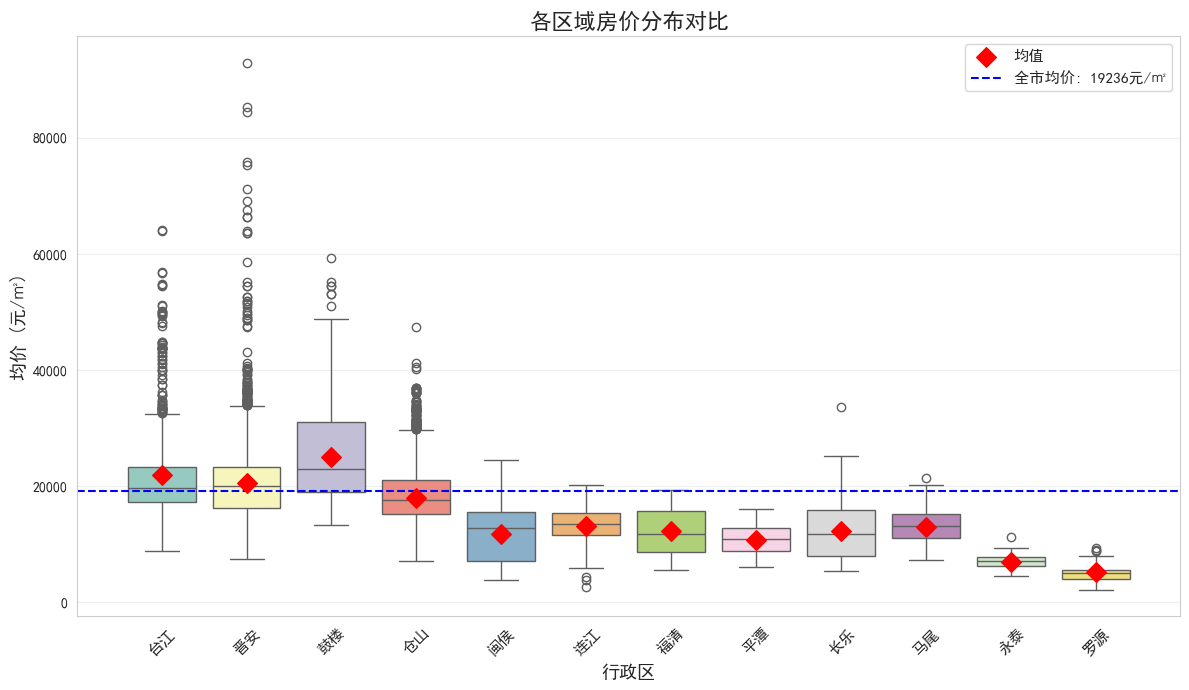

In [18]:
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False  

fig, ax = plt.subplots(figsize=(12, 7))

# 绘制箱线图
sns.boxplot(data=df_clean, x='市区', y='均价数值', ax=ax, palette='Set3')

# 添加均值点
means = df_clean.groupby('市区')['均价数值'].mean()
for i, region in enumerate(df_clean['市区'].unique()):
    ax.scatter(i, means[region], color='red', s=100, zorder=10, marker='D', 
               label='均值' if i == 0 else "")

ax.set_title('各区域房价分布对比', fontsize=16, fontweight='bold')
ax.set_xlabel('行政区', fontsize=13)
ax.set_ylabel('均价 (元/㎡)', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# 添加水平参考线
city_avg = df_clean['均价数值'].mean()
ax.axhline(y=city_avg, color='blue', linestyle='--', linewidth=1.5, 
           label='全市均价: {:.0f}元/㎡'.format(city_avg))
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

### 图1：各区域均价分布

> 该图展示了各行政区房源均价的分布特征，全市均价线为参考基准。

**图表观察：**

- **鼓楼区**均价最高，中位数约28000元/㎡，且存在多个高价极端值，核心区溢价明显
- **台江区**均价次之，中位数约28000元/㎡，分布较为集中，波动较小
- **晋安区**均价中位数约22000元/㎡，箱体最宽（房源数最多），价格跨度大
- **仓山区**均价中位数约18000元/㎡，与晋安区相近
- **闽侯、连江、福清、平潭、长乐**均价中位数集中在10000-12000元/㎡区间，属于价格洼地
- 全市均价约20000元/㎡（蓝色虚线），仅鼓楼区和台江区明显高于该线，其余区域均低于或接近全市均价

**分析结论：**

福州二手房市场呈现**明显的价格梯度**：鼓楼、台江为第一梯队（均价28000元/㎡左右）；晋安为第二梯队（22000元/㎡）；仓山为第三梯队（18000元/㎡）；远郊县市为第四梯队（10000-12000元/㎡）。**核心区与远郊的均价差距接近3倍**。

### 图表 2：面积-总价关系（分区域散点图+趋势线）

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

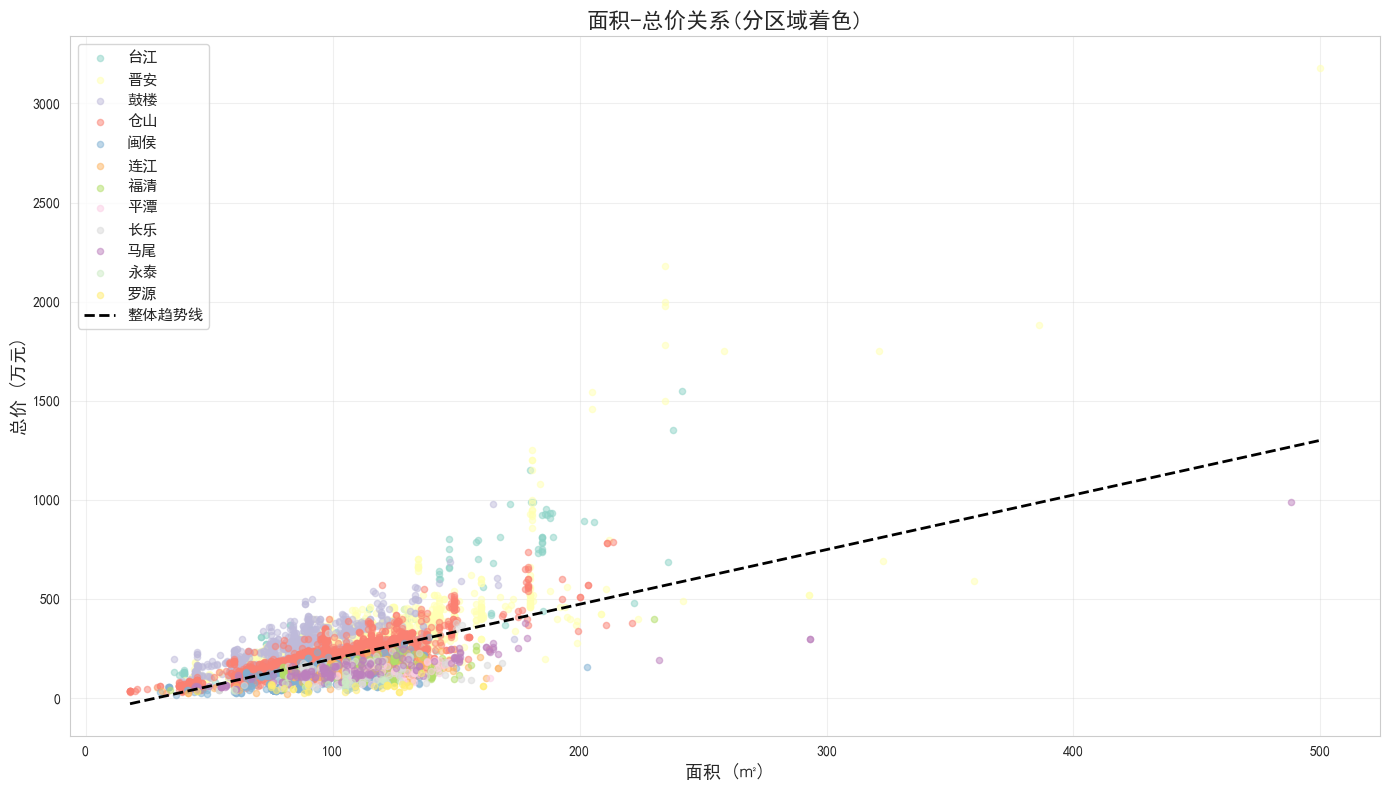

In [19]:
fig, ax = plt.subplots(figsize=(14, 8))

# 按区域着色
regions = df_clean['市区'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(regions)))

for i, region in enumerate(regions):
    subset = df_clean[df_clean['市区'] == region]
    ax.scatter(subset['面积数值'], subset['总价数值'], 
               alpha=0.5, s=20, label=region, color=colors[i])

# 整体趋势线
z = np.polyfit(df_clean['面积数值'], df_clean['总价数值'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['面积数值'].min(), df_clean['面积数值'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2, label='整体趋势线')

ax.set_title('面积-总价关系(分区域着色)', fontsize=16, fontweight='bold')
ax.set_xlabel('面积 (㎡)', fontsize=13)
ax.set_ylabel('总价 (万元)', fontsize=13)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 图2：面积-总价关系（分区域着色）

> 该图展示了各区域面积与总价的散点分布及整体趋势线。

**图表观察：**

- 面积与总价呈现**明显的正相关关系**，整体趋势线向右上方倾斜
- **鼓楼区**在同面积条件下总价更高（散点位于整体趋势线上方），体现了核心区的地段溢价
- **大面积房源（>150㎡）** 主要集中在晋安区和仓山区，供应较为充足
- 整体趋势线斜率约为 **2-2.5万元/㎡**，即面积每增加1㎡，总价约增加2-2.5万元
- 存在部分明显偏离趋势线的点（高溢价或低折价），可能与特殊户型、小区品质或挂牌定价策略有关

**分析结论：**

面积是决定总价的基础因素，但**区域属性显著影响同面积下的价格水平**。鼓楼区在同面积下比晋安/仓山贵约5000-8000元/㎡，再次验证了"区位溢价"的存在。购房者在预算有限时，可选择晋安、仓山的大面积房源，牺牲区位换取居住空间。

### 图表 3：TOP10户型分布

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

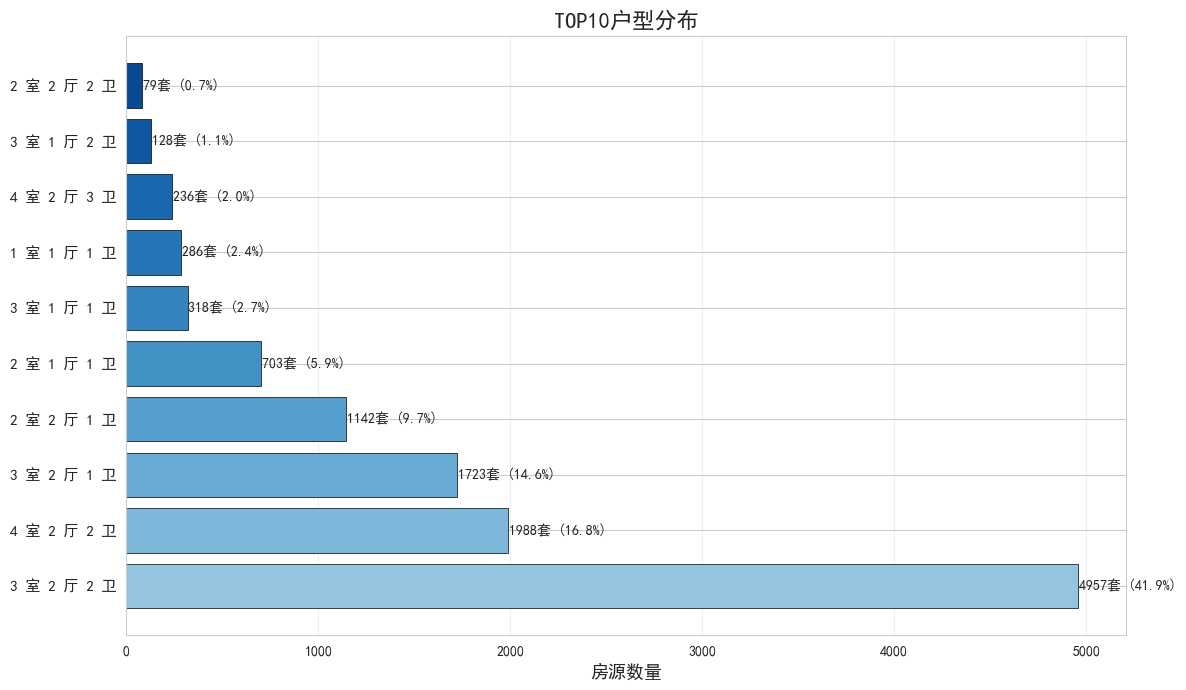

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

top_rooms = df_clean['户型'].value_counts().head(10)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rooms)))

bars = ax.barh(range(len(top_rooms)), top_rooms.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_rooms)))
ax.set_yticklabels(top_rooms.index, fontsize=11)
ax.set_xlabel('房源数量', fontsize=13)
ax.set_title('TOP10户型分布', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            '{}套 ({:.1f}%)'.format(int(bar.get_width()), 
                                    bar.get_width()/len(df_clean)*100),
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 图3：各户型房源数量分布

> 该图展示了不同户型的供应量及占比情况。

**图表观察：**

- **3室2厅2卫** 以 **4957套（占比41.9%）** 遥遥领先，是福州二手房市场的绝对主力户型
- **4室2厅2卫（1988套，16.8%）** 和 **3室2厅1卫（1723套，14.6%）** 分列第二、第三
- **2室2厅1卫（1142套，9.7%）** 和 **2室1厅1卫（703套，5.9%）** 合计约1845套，满足刚需入门需求
- 1室小户型供应最少（286套，2.4%），属于小众市场
- TOP3户型（3室2厅2卫 + 4室2厅2卫 + 3室2厅1卫）合计占比约 **73.3%**

**分析结论：**

**三房及以上户型占比超过70%**，反映了福州二手房市场以 **改善型需求** 为主导。3室2厅2卫的绝对优势地位，与第6.2节中"该户型面积约101㎡、总价约185万元"的统计特征相互印证，说明 **100㎡左右的三房两卫** 是目前福州市场最受认可的标准改善户型。刚需客户在2室户型中的选择也较为丰富（合计约1845套），入门门槛相对友好。

### 图表 4：性价比指数分布（直方图+核密度曲线）

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

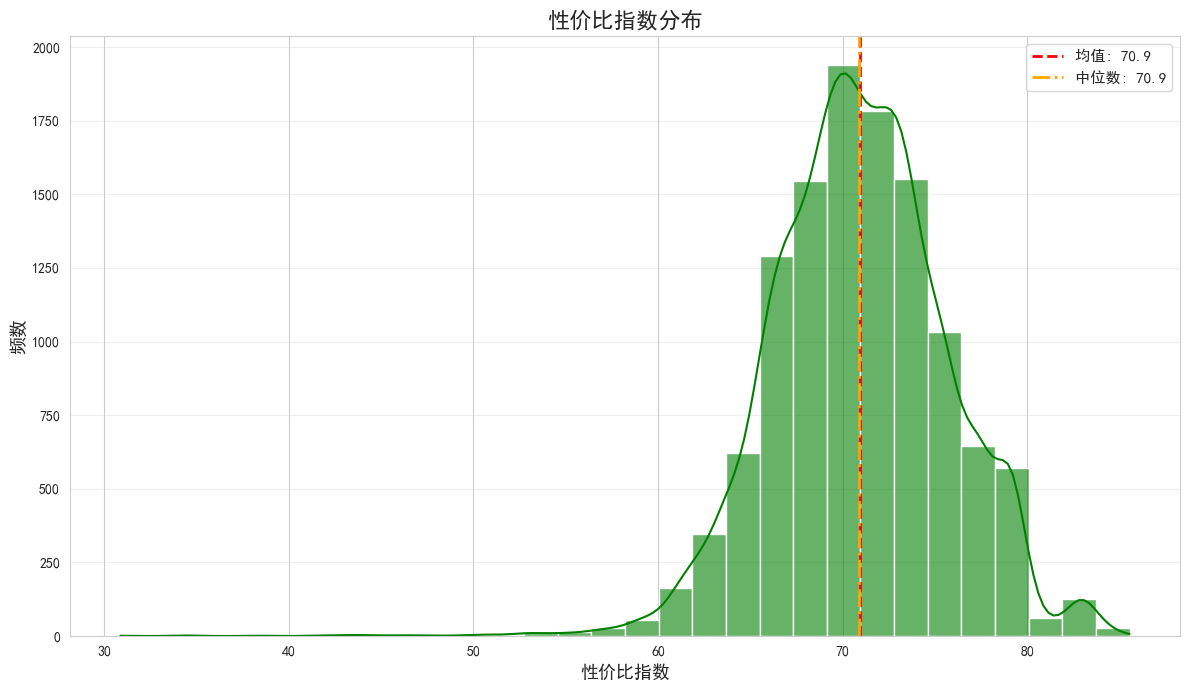

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.histplot(df_score['性价比指数'], bins=30, kde=True, ax=ax, color='green', alpha=0.6)

# 添加统计线
mean_val = df_score['性价比指数'].mean()
median_val = df_score['性价比指数'].median()

ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
           label='均值: {:.1f}'.format(mean_val))
ax.axvline(median_val, color='orange', linestyle='-.', linewidth=2, 
           label='中位数: {:.1f}'.format(median_val))

ax.set_title('性价比指数分布', fontsize=16, fontweight='bold')
ax.set_xlabel('性价比指数', fontsize=13)
ax.set_ylabel('频数', fontsize=13)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 图4：性价比指数分布

> 该图展示了所有房源的性价比指数分布形态。

**图表观察：**

- 性价比指数均值约为 **70.9分**，中位数也约为 **70.9分**，两者几乎相等
- 分布呈 **对称形态**，说明市场整体性价比水平较为均衡，不存在严重的极端值偏斜
- 大部分房源集中在 **60-80分** 区间
- 存在少量 **高分房源（>80分）**，即图3中TOP20推荐的高性价比房源
- 低分房源（<60分）较少，主要对应鼓楼区高价低配的老破小房源

**分析结论：**

性价比指数的对称分布说明该评价体系对各区域房源较为公平，未出现系统性偏差。均值与中位数相等，表明没有极端值拉偏整体水平，市场整体性价比分布健康。购房者可重点关注 **指数>75分** 的房源，在同等预算下获得更好的综合品质。

### 图表5：各区域性价比排名（水平条形图）

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

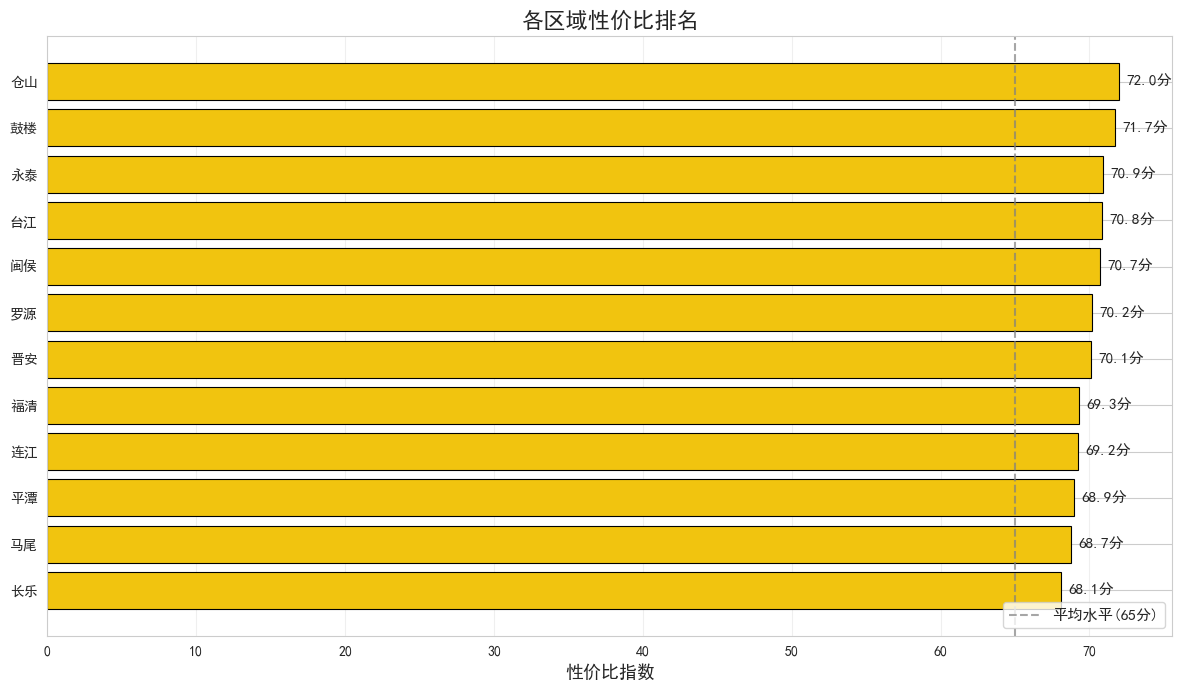

In [22]:
fig, ax = plt.subplots(figsize=(12, 7))

region_value_sorted = region_value.sort_values('性价比指数', ascending=True)

colors5 = []
for x in region_value_sorted['性价比指数']:
    if x >= 75:
        colors5.append('#2ECC71')      # 绿色-高性价比
    elif x >= 65:
        colors5.append('#F1C40F')      # 黄色-中等
    else:
        colors5.append('#E74C3C')      # 红色-低性价比

bars = ax.barh(region_value_sorted.index, region_value_sorted['性价比指数'], color=colors5, 
               edgecolor='black', linewidth=0.8)

ax.set_xlabel('性价比指数', fontsize=13)
ax.set_title('各区域性价比排名', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            '{:.1f}分'.format(bar.get_width()), va='center', fontsize=11, fontweight='bold')

# 添加参考线
ax.axvline(x=65, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='平均水平(65分)')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

### 图5：各区域性价比排名

> 该图展示了各行政区的平均性价比指数及与平均水平的对比。

**图表观察：**

- **仓山区（72.0分）** 性价比最高，排名第一
- **鼓楼区（71.7分）** 紧随其后，排名第二，仅比仓山低0.3分
- **永泰（70.9分）、台江（70.8分）、闽侯（70.7分）、罗源（70.2分）、晋安（70.1分）** 处于第三梯队，均略高于70分
- **福清（69.3分）、连江（69.2分）、平潭（68.9分）、马尾（68.7分）、长乐（68.1分）** 低于70分，排名靠后
- 全市平均性价比水平约为 **65分**（图中虚线），所有区域均高于该线

**分析结论：**

各区域性价比指数差距较小（最高72.0，最低68.1，极差仅3.9分），说明各区域在"价格+区位+户型+热度"的综合评价下差异不大。**仓山和鼓楼并列第一梯队**（指数>71.5），但逻辑不同：仓山靠 **低均价**（17979元/㎡）取胜，鼓楼靠 **高区位得分**（核心区）弥补了高均价的劣势。购房者可依据自身偏好选择——追求空间和价格选仓山，追求地段和配套选鼓楼。远郊区域（永泰、罗源等）虽均价极低，但因区位得分低，性价比指数并未显著高于市区。


### 图表6: 总价区间与单价区间分布（双柱状图）

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

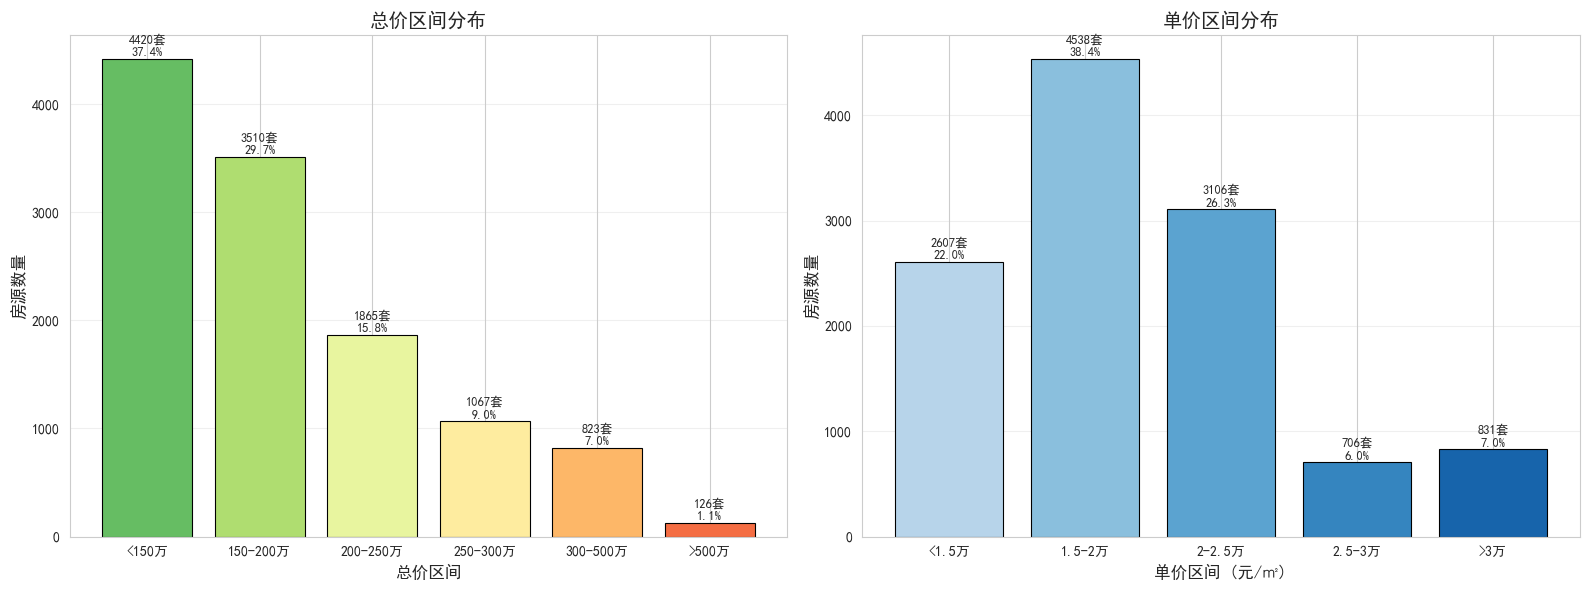

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：总价区间分布
ax1 = axes[0]
total_dist = df_clean['总价分类'].value_counts().sort_index()
colors6 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(total_dist)))
bars1 = ax1.bar(total_dist.index, total_dist.values, color=colors6, edgecolor='black', linewidth=0.8)
ax1.set_xlabel('总价区间', fontsize=12)
ax1.set_ylabel('房源数量', fontsize=12)
ax1.set_title('总价区间分布', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             '{}套\n{:.1f}%'.format(int(height), height/len(df_clean)*100),
             ha='center', va='bottom', fontsize=9)

# 右图：单价区间分布
ax2 = axes[1]
price_dist = df_clean['单价分类'].value_counts().sort_index()
colors6_2 = plt.cm.Blues(np.linspace(0.3, 0.8, len(price_dist)))
bars2 = ax2.bar(price_dist.index, price_dist.values, color=colors6_2, edgecolor='black', linewidth=0.8)
ax2.set_xlabel('单价区间 (元/㎡)', fontsize=12)
ax2.set_ylabel('房源数量', fontsize=12)
ax2.set_title('单价区间分布', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             '{}套\n{:.1f}%'.format(int(height), height/len(df_clean)*100),
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### 图6：总价区间与单价区间分布

> 该图展示了房源在不同总价和单价区间的分布情况。

**图表观察：**

**总价分布：**
- **<150万（4420套，37.4%）** 占比最高，刚需入门选择充足
- **150-200万（3510套，29.7%）** 为第二大主力区间
- **200-250万（1865套，15.8%）** 位列第三
- **250-300万（1067套，9.0%）**、**300-500万（823套，7.0%）**、**>500万（126套，1.1%）** 依次递减

**单价分布：**
- **1.5-2万/㎡（4538套）** 占比最高
- **2-2.5万/㎡（3106套）** 为第二大区间
- **<1.5万/㎡（2607套）** 位列第三
- **>3万/㎡（831套）** 和 **2.5-3万/㎡（706套）** 占比最少

**分析结论：**

总价分布呈 **金字塔型**：底部（150万以下）最宽，向上逐级收窄。**200万以内房源合计占比67.1%**，是福州二手房市场的绝对主力价格带。单价分布呈 **中间大、两头小** 的橄榄型：1.5-2.5万/㎡为中坚区间，合计占比约 **64.5%**。单价低于1.5万或高于2.5万的房源各占约20%，市场两端供给相对有限。

### 图表7: 楼层与朝向对价格的影响（分面柱状图）

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

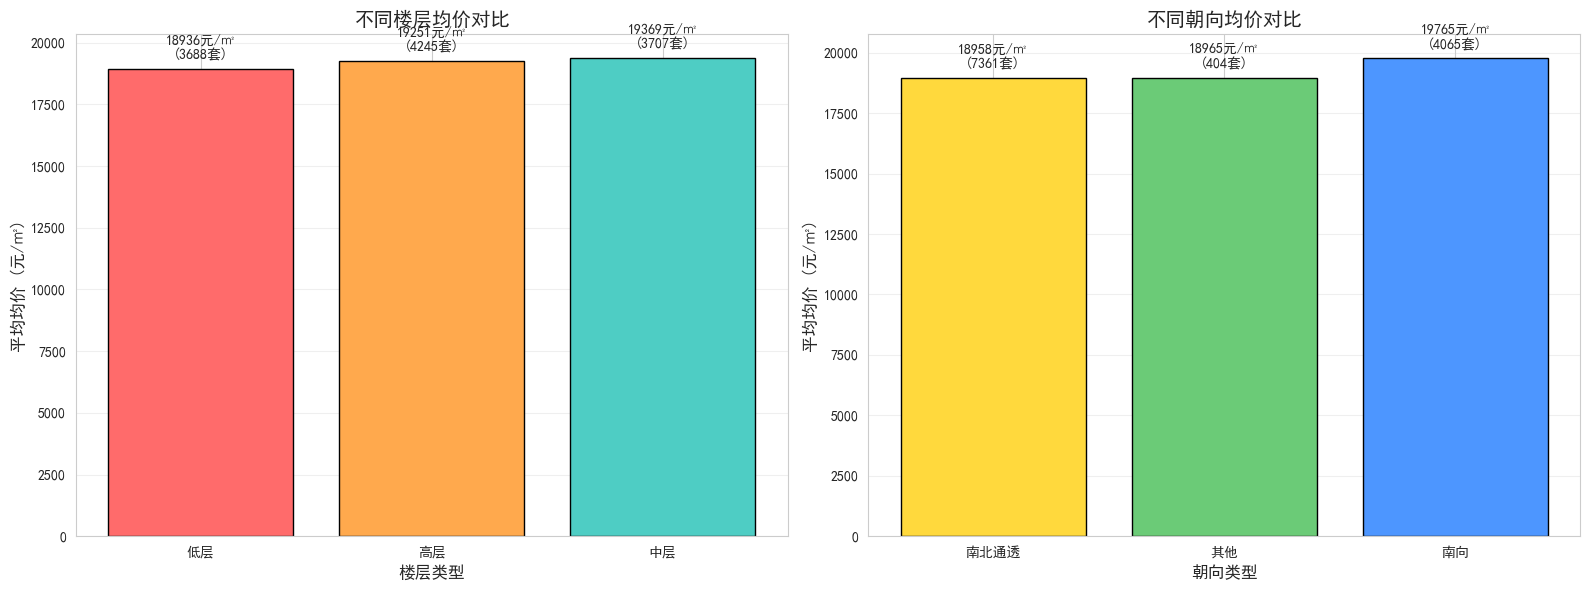

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：不同楼层均价对比
ax1 = axes[0]
floor_avg = df_clean.groupby('楼层类型')['均价数值'].mean().dropna().sort_values()
floor_count = df_clean.groupby('楼层类型')['均价数值'].count().dropna()
colors7 = ['#FF6B6B', '#FFA94D', '#4ECDC4']

bars1 = ax1.bar(floor_avg.index, floor_avg.values, color=colors7, edgecolor='black', linewidth=1)
ax1.set_xlabel('楼层类型', fontsize=12)
ax1.set_ylabel('平均均价 (元/㎡)', fontsize=12)
ax1.set_title('不同楼层均价对比', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for i, bar in enumerate(bars1):
    height = bar.get_height()
    count = floor_count[floor_avg.index[i]]
    ax1.text(bar.get_x() + bar.get_width()/2., height + 300,
             '{:.0f}元/㎡\n({}套)'.format(height, int(count)),
             ha='center', va='bottom', fontsize=10)

# 右图：不同朝向均价对比
ax2 = axes[1]
ori_avg = df_clean.groupby('朝向类型')['均价数值'].mean().dropna().sort_values()
ori_count = df_clean.groupby('朝向类型')['均价数值'].count().dropna()
colors7_2 = ['#FFD93D', '#6BCB77', '#4D96FF']

bars2 = ax2.bar(ori_avg.index, ori_avg.values, color=colors7_2, edgecolor='black', linewidth=1)
ax2.set_xlabel('朝向类型', fontsize=12)
ax2.set_ylabel('平均均价 (元/㎡)', fontsize=12)
ax2.set_title('不同朝向均价对比', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for i, bar in enumerate(bars2):
    height = bar.get_height()
    count = ori_count[ori_avg.index[i]]
    ax2.text(bar.get_x() + bar.get_width()/2., height + 300,
             '{:.0f}元/㎡\n({}套)'.format(height, int(count)),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 图7：楼层与朝向对价格的影响

> 该图展示了不同楼层和朝向的均价对比。

**图表观察：**

**楼层方面：**
- **中层（19369元/㎡）** 均价最高，房源3707套
- **高层（19251元/㎡）** 次之，房源4245套（最多）
- **低层（18936元/㎡）** 最低，房源3688套
- 楼层间最大价差仅 **433元/㎡**（中层-低层），溢价不足3%

**朝向方面：**
- **南向（19765元/㎡）** 均价最高，房源4065套
- **其他朝向（18965元/㎡）** 次之，房源仅404套
- **南北通透（18958元/㎡）** 最低，房源7361套（最多）
- 南向与其他朝向价差约 **800元/㎡（约4%）**

**分析结论：**

楼层和朝向对福州二手房价格的影响均有限（楼层差异<3%，朝向差异<5%），**远低于区域差异（鼓楼vs罗源相差近5倍）和户型差异（1室vs4室相差约2000元/㎡）**。

两个反直觉的发现值得注意：
1. **高层均价低于中层**（19251 < 19369），与"越高越贵"的常识不符
2. **南北通透均价低于南向**（18958 < 19765），与"南北通透最佳"的常识不符

这说明在福州二手房市场中，楼层和朝向的溢价效应被 **区域混杂效应** 所掩盖——南北通透房源大量集中在晋安、仓山等均价较低的区域，而南向房源中鼓楼、台江等高价位区域占比更高。购房者在选房时，**应先锁定区域，再考虑楼层和朝向**。

## 九、最终结论

### 9.1 核心发现

**发现1：仓山区是福州二手房市场性价比最高的区域**

| 指标 | 仓山区 | 全市平均 | 对比 |
|------|--------|---------|------|
| 均价 | 17979元/㎡ | 19236元/㎡ | 低1257元/㎡ |
| 性价比指数 | 72.0分 | 约65分 | 高7分 |
| 房源数量 | 3926套 | - | 供应充足 |

仓山区性价比指数72.0，排名第一，鼓楼区（71.7）紧随其后，两者差距极小（仅0.3分）。仓山靠低均价取胜，鼓楼靠高区位得分弥补高均价。

**发现2：3室2厅2卫是绝对主流户型**

| 指标 | 数值 |
|------|------|
| 房源数量 | 4957套 |
| 占比 | 41.9% |
| 平均面积 | 101.19㎡ |
| 平均总价 | 185.33万元 |
| 平均均价 | 18313.58元/㎡ |

该户型在晋安（1773套）和仓山（1810套）最为集中，反映了改善型需求的市场主导地位。三房及以上户型合计占比超过70%。

**发现3：面积是决定总价的重要因素，但非唯一因素**

- 面积与总价的相关系数为 **0.643**，呈中等偏正相关
- 分区域来看，马尾（0.903）和台江（0.826）相关性最强，面积几乎直接决定总价
- 鼓楼区相关系数较低（0.556），说明学区、地段等非面积因素在核心区定价中权重更高

**发现4：楼层和朝向对价格的影响有限**

- 楼层间最大价差仅 **433元/㎡**（中层 vs 低层），溢价不足3%
- 南向均价（19765元/㎡）略高于南北通透（18958元/㎡），溢价约4%
- 选对区域远比选楼层和朝向更重要

**发现5：福州二手房市场以刚需和首次改善为主导**

- **200万以内房源占比67.1%**，是绝对主力价格带
- 总价分布呈金字塔型：150万以下（37.4%）> 150-200万（29.7%）> 200-250万（15.8%）> 250万以上（17.1%）
- 单价分布呈橄榄型：1.5-2.5万/㎡为中坚区间，合计占比约64.5%


### 9.2 各维度结论汇总

| 分析维度 | 核心发现 | 数据支撑 |
|---------|---------|---------|
| 价格水平 | 全市均价19236元/㎡，总价中位数173万元 | 第5.1节 |
| 区域差异 | 仓山性价比最高（72.0分），鼓楼价格最高（25083元/㎡） | 第6.1节、第7.2节 |
| 户型特征 | 3室2厅2卫是绝对主流，占比41.9% | 第6.2节 |
| 面积影响 | 相关系数0.643，中等偏正相关 | 第6.3节 |
| 总价分布 | 200万以内占比67.1%，金字塔型结构 | 第6.4节 |
| 楼层影响 | 楼层溢价不足3%，影响极小 | 第6.5节 |
| 朝向影响 | 南向略贵（19765元/㎡），差距不足5% | 第6.6节 |
| 性价比之王 | 仓山区（72.0分） | 第7.2节 |


### 9.3 购房建议

| 需求类型 | 推荐区域 | 推荐户型 | 预算范围 | 推荐理由 |
|---------|---------|---------|---------|---------|
| 刚需首套 | 晋安区 | 2室/小3室 | 150万以下 | 房源最多（4346套），选择空间大 |
| 改善换房 | 仓山区 | 3室2厅2卫 | 150-200万 | 性价比最高，配套成熟 |
| 追求性价比 | 仓山区 | 3室2厅2卫 | 150-200万 | 均价最低，指数最高 |
| 学区/地段 | 鼓楼区 | 2室/小3室 | 200万以上 | 核心区位，但需接受较高单价 |
| 楼层选择 | 各楼层差异极小 | 无需特别关注 | - | 楼层对价格影响不足3% |
| 朝向选择 | 南向略优 | 优先南向 | - | 南向仅比南北通透贵4%，采光更好 |


### 9.4 数据局限性

1. **挂牌价 ≠ 成交价**：实际成交可能存在议价空间，分析结论需结合实际情况调整

2. **数据时效性**：数据为2026年6月时点数据，市场受政策、经济环境影响会有波动

3. **远郊样本较少**：罗源（35套）、永泰（19套）样本量有限，相关结论需谨慎参考

4. **缺失变量**：数据不包含学区划片、装修状况、物业费、具体楼层位置等重要因素，这些因素在实际购房决策中同样关键